In [1]:
import os
import random
import math
import numpy as np
import pandas as pd
import time
import copy
import requests
import shutil
import cv2

from tqdm import tqdm
from glob import glob
from zipfile import ZipFile
from dataclasses import dataclass
from typing import List, Tuple, Union
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchinfo import summary
from torch.utils.data import (DataLoader, 
                              Dataset, 
                              random_split, 
                              WeightedRandomSampler)
from torch.optim import lr_scheduler

from torchvision.models import (resnet18, 
                                resnet50, 
                                ResNet50_Weights, 
                                efficientnet_v2_s, 
                                EfficientNet_V2_S_Weights)
from torchvision import datasets, transforms as T
from torchvision.transforms import functional

from torch.utils.tensorboard import SummaryWriter
from torchmetrics import MeanMetric
from torchmetrics.classification import MulticlassAccuracy, MulticlassConfusionMatrix

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter)
import seaborn as sns


2026-07-28 12:41:44.674299: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1785242504.699136     200 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1785242504.706077     200 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1785242504.724067     200 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1785242504.724086     200 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1785242504.724089     200 computation_placer.cc:177] computation placer alr

In [2]:
bold = f"\033[1m"
reset = f"\033[0m"

In [3]:
# TO check whether all the images contain jpg format

path_img = '/kaggle/input/open-cv-py-torch-project-2-classification-round-4/images/images/*.*'
other_files = [i for i in glob(path_img) if not i.lower().endswith('.jpg')]
print(len(other_files))

0


In [4]:
# paths 
root_dir = '/kaggle/working/'
dataroot = os.path.join(root_dir, 'datasets')
train_data_path = os.path.join(root_dir, 'train.csv')
valid_data_path = os.path.join(root_dir, 'valid.csv')
test_data_path = os.path.join(root_dir, 'test.csv')
train_img_datasets = os.path.join(dataroot, 'train')
valid_img_datasets = os.path.join(dataroot, 'valid')
test_img_datasets = os.path.join(dataroot, 'test')
model_checkpoint = os.path.join(root_dir, 'model_checkpoint/ken_food_models')

In [5]:
# creating folders in the working directory
os.makedirs(train_img_datasets, exist_ok = True)
os.makedirs(valid_img_datasets, exist_ok = True)
os.makedirs(test_img_datasets, exist_ok = True)
os.makedirs(model_checkpoint, exist_ok = True)

In [6]:
# copying test.csv from input to working
shutil.copy2('/kaggle/input/open-cv-py-torch-project-2-classification-round-4/test.csv',
             test_data_path)

'/kaggle/working/test.csv'

In [7]:
# reading csv files of train.csv
df_train= pd.read_csv('/kaggle/input/open-cv-py-torch-project-2-classification-round-4/train.csv')

In [8]:
# splitting the data into train and valid
train_data,valid_data = train_test_split(df_train,
                                         test_size = 0.2,
                                         random_state  = 42)

In [9]:
# creating train and valid csv files
train_data.to_csv(train_data_path, index = False)
valid_data.to_csv(valid_data_path, index = False)

In [10]:
# function for Copying images from images folder to specified directory
def image_copy(name_path, src_path, dst_path):
    data = pd.read_csv(name_path)
    names = data.iloc[:,0].tolist()

    for i in names:
        name_jpg = str(i) + '.jpg'

        src_image = os.path.join(src_path, name_jpg)
        dst_image = os.path.join(dst_path, name_jpg)

        if os.path.exists(src_image):
            shutil.copy2(src_image, dst_image)
        else:
            print(f"Warning: {src_image} not found in {dst_image}")
            
            

In [11]:
# Copying images from images folder to specified train directory
image_copy(name_path = train_data_path,
           src_path = '/kaggle/input/open-cv-py-torch-project-2-classification-round-4/images/images',
           dst_path = train_img_datasets)

In [12]:
# Copying images from images folder to specified test directory
image_copy(name_path = test_data_path,
           src_path = '/kaggle/input/open-cv-py-torch-project-2-classification-round-4/images/images',
           dst_path = test_img_datasets)

In [13]:
# Copying images from images folder to specified test directory
image_copy(name_path = valid_data_path,
           src_path = '/kaggle/input/open-cv-py-torch-project-2-classification-round-4/images/images',
           dst_path = valid_img_datasets)

## <font style="color:green">1. Data Loader [10 Points]</font>

In this section, you have to write a class or methods, which will be used to get training and validation data loader.

You need to write a custom dataset class to load data.

**Note; There is   no separate validation data. , You will thus have to create your own validation set, by dividing the train data into train and validation data. Usually, we do 80:20 ratio for train and validation, respectively.**


For example:

```python
class KenyanFood13Dataset(Dataset):
    """
    
    """
    
    def __init__(self, *args):
    ....
    ...
    
    def __getitem__(self, idx):
    ...
    ...
    

```


```python
def get_data(args1, *args):
    ....
    ....
    return train_loader, test_loader
```

In [14]:
class Kenyanfood(Dataset):
    def __init__(self, csv_path, 
                 data_root, transform = None,
                 class_to_idx = None):
        """
        args:
        csv_path : path of csv files 'train.csv', 'valid.csv' and test.csv
        img_dir : path of images
        transform : preprocessing
        class_to_idx : text to number mapping
        
        """
        
        self.df = pd.read_csv(csv_path)
        self.data_root = data_root
        self.transform = transform

        # To check whether it is a test set
        self.is_test = 'class' not in self.df.columns
        
        # label encoding
        if not self.is_test:    
            if class_to_idx is None:
                unique_classes = sorted(self.df['class'].unique())
                self.class_to_idx = {class_name:idx for idx, class_name in enumerate(unique_classes)}
            else:
                self.class_to_idx = class_to_idx
        else:
            self.class_to_idx = None

    def __len__(self):
        """
            return length of the dataset
        """
        return len(self.df)

    def __getitem__(self, idx):
        # get the row of the data
        row = self.df.iloc[idx]
        
        # extract the image name
        img_name = str(row['id']) + '.jpg'
        img_path = os.path.join(self.data_root, img_name)

        # Read the image
        image = cv2.imread(img_path, 1)
        
        # Convert the image from bgr to rgb
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # converting to PIL image
        image = Image.fromarray(image)

        # apply transforms and return
        if self.transform:
            image = self.transform(image)

        # return only the image in case of test set
        if self.is_test:
            return image, str(row['id'])
        else:
            # convert the label into numeric
            label = row['class']
            numerical_label = self.class_to_idx[label]
            return image, torch.tensor(numerical_label)
        

In [15]:
# image preprocessing techniques applied to valid and test set
def image_preprocess_transforms(img_height, img_width, 
                                mean, std):
    preprocess = T.Compose([
        T.Resize((img_height, img_width), antialias = True),
        T.ToTensor(),
        T.Normalize(mean, std)
    ])

    return preprocess

In [16]:
def get_data(img_height, img_width, 
             batch_size, num_workers = 1):

    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    #mean = [0.5768, 0.4622, 0.3460]
    #std = [0.2383, 0.2464, 0.2465]
    
    common_transforms = image_preprocess_transforms(img_height, img_width,
                                                    mean, std)

    """# preprocessing applied to train images
    train_transforms = T.Compose([ 
        # Geometric & Scale Augmentations
        # Instead of a fixed Resize, this randomly crops a portion of the image 
        # and resizes it to 224x224. This makes the model invariant to zoom/scale.
        T.RandomResizedCrop((img_height, img_width), 
                            scale = (0.75, 1.0), 
                            ratio = (0.9, 1.1)),
        
        # Randomly flips the plate of food horizontally. 
        # A chapati or bowl of ugali is still the same food if flipped!
        T.RandomHorizontalFlip(p = 0.5),

        T.RandAugment(num_ops = 2, 
                      magnitude = 5),  # Auto-augmentation policy
    
        # Randomly rotates the image slightly (up to 15 degrees). 
        # Accounts for different camera angles when people take photos of food.
        T.RandomRotation(degrees = 15),
        
        # Photometric (Lighting) Augmentations
        # Subtly adjusts brightness, contrast, and saturation. 
        # Kept conservative (0.1) so it doesn't change a brown stew into a green one.
        T.ColorJitter(brightness = 0.2, 
                      contrast = 0.2, 
                      saturation = 0.2, 
                      hue = 0.05),

        T.RandomGrayscale(p=0.1),
 
        T.ToTensor(),
        
        T.RandomErasing(p=0.3, scale=(0.02, 0.15), ratio=(0.3, 3.3)),

        T.Normalize(mean = mean, std = std),
    ])"""

    train_transforms = T.Compose([
    T.RandomResizedCrop((img_height, img_width), 
                        scale=(0.75, 1.0), 
                        ratio=(0.9, 1.1)),
        
    T.RandomHorizontalFlip(p=0.5),
    
    # RandAugment FIRST (before manual color ops) - let it choose 2 ops cleanly
    T.RandAugment(num_ops=2, 
                  magnitude=5),
    
    T.RandomRotation(degrees=15),  # Reduced from 15 - food angles are limited
    
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    
    # REMOVED: RandomGrayscale
    # Food color is critical (white ugali vs brown pilau vs green sukuma)
    # Forcing grayscale 10% of the time hurts more than it helps
    
    T.ToTensor(),
    
    T.RandomErasing(p=0.2, scale=(0.02, 0.15), ratio=(0.3, 3.3)),
    
    T.Normalize(mean=mean, std=std),
])


    train_dataset  = Kenyanfood(
        csv_path = train_data_path, 
        data_root = train_img_datasets, 
        transform = train_transforms,
        class_to_idx = None
    )

    valid_dataset = Kenyanfood(
        csv_path = valid_data_path, 
        data_root = valid_img_datasets, 
        transform = common_transforms,
        class_to_idx = train_dataset.class_to_idx
    )

    test_dataset = Kenyanfood(
        csv_path = test_data_path, 
        data_root = test_img_datasets, 
        transform = common_transforms,
    )

    # Compute class weights for balanced sampling
    train_labels = train_dataset.df['class'].map(train_dataset.class_to_idx).values
    class_counts = np.bincount(train_labels)
    class_weights = 1.0 / class_counts
    sample_weights = class_weights[train_labels]

    sampler = WeightedRandomSampler(
        weights = torch.DoubleTensor(sample_weights),
        num_samples = len(sample_weights),
        replacement = True
    )

    # train dataloader
    train_loader = DataLoader(train_dataset, batch_size = batch_size,
                              sampler = sampler, num_workers = num_workers)
                              

    # valid dataloader
    valid_loader = DataLoader(valid_dataset, batch_size = batch_size,
                              shuffle = False, num_workers = num_workers)

    # test dataloader
    test_loader = DataLoader(test_dataset, batch_size = batch_size,
                              shuffle = False, num_workers = num_workers)

    return (train_loader, 
            valid_loader, 
            test_loader, 
            train_dataset.class_to_idx)

## <font style="color:green">2. Configuration [5 Points]</font>

**Define your configuration here.**

For example:


```python
@dataclass
class TrainingConfiguration:
    '''
    Describes configuration of the training process
    '''
    batch_size: int = 10 
    epochs_count: int = 50  
    init_learning_rate: float = 0.1  # initial learning rate for lr scheduler
    log_interval: int = 5  
    test_interval: int = 1  
    data_root: str = "/kaggle/input/opencv-pytorch-project-2-classification-round-3" 
    num_workers: int = 2  
    device: str = 'cuda'  
    
```

In [17]:
@dataclass(frozen=True)
class DatasetConfig:
    NUM_CLASSES: int = 13
    IMG_WIDTH:   int = 224
    IMG_HEIGHT:  int = 224
    BATCH_SIZE:      int = 32
    NUM_WORKERS:     int = 4

@dataclass(frozen=True)
class TrainingConfig:  
    EPOCHS:          int = 120
    LEARNING_RATE: float = 1e-3
    WEIGHT_DECAY:    float = 5e-3
    LABEL_SMOOTHING: float = 0.15
    DROPOUT: float = 0.5
    CHECKPOINT_DIR:  str = os.path.join('model_checkpoint', 'kenya_food_models')
    LOG_DIR:        str   = "kenyan_food_res18"
    TEST_INTERVAL:  int   = 1
    MIXUP_ALPHA:     float = 0.4       # Mixup augmentation strength
    MIXUP_PROB:      float = 1e-2
    AUG_CUTOFF_EPOCH: int = 40
    GRAD_CLIP:       float = 1.0
    EMA_DECAY:       float = 0.9998    # Exponential Moving Average decay


@dataclass(frozen=True)
class InferenceConfig:
    BATCH_SIZE:  int = 32

In [18]:
def system_config(SEED_VALUE=42, package_list=None):
    """
    Configures the system environment for PyTorch-based operations.

    Args:
        SEED_VALUE (int): Seed value for random number generation. Default is 42.
        package_list (str): String containing a list of additional packages to install
        for Google Colab or Kaggle. Default is None.

    Returns:
        tuple: A tuple containing the device name as a string and a boolean indicating GPU availability.
    """

    random.seed(SEED_VALUE)
    np.random.seed(SEED_VALUE)
    torch.manual_seed(SEED_VALUE)

    def is_running_in_colab():
        return 'COLAB_GPU' in os.environ

    def is_running_in_kaggle():
        return 'KAGGLE_KERNEL_RUN_TYPE' in os.environ

    #--------------------------------
    # Check for availability of GPUs.
    #--------------------------------
    if torch.cuda.is_available():
        print('Using CUDA GPU')

        # This section for installing packages required by Colab.
        if is_running_in_colab() or is_running_in_kaggle():
            print('Installing required packages...')
            !pip install {package_list}

        # Set the device to the first CUDA device.
        DEVICE = torch.device('cuda')
        print("Device: ", DEVICE)
        GPU_AVAILABLE = True

        torch.cuda.manual_seed(SEED_VALUE)
        torch.cuda.manual_seed_all(SEED_VALUE)

        # Performance and deterministic behavior.
        torch.backends.cudnn.enabled = True       # Provides highly optimized primitives for DL operations.
        torch.backends.cudnn.deterministic = True # Insures deterministic even when above cudnn is enabled.
        torch.backends.cudnn.benchmark = False    # Setting to True can cause non-deterministic behavior.

    elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
        print('Using Apple Silicon GPU')

        # Set the device to the Apple Silicon GPU Metal Performance Shader (MPS).
        DEVICE = torch.device("mps")
        print("Device: ", DEVICE)
        # Environment variable that allows PyTorch to fall back to CPU execution
        # when encountering operations that are not currently supported by MPS.
        os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'
        GPU_AVAILABLE = True

        torch.mps.manual_seed(SEED_VALUE)
        torch.use_deterministic_algorithms(True)

    else:
        print('Using CPU')
        DEVICE = torch.device('cpu')
        print("Device: ", DEVICE)
        GPU_AVAILABLE = False

        if is_running_in_colab() or is_running_in_kaggle():
            print('Installing required packages...')
            !pip install {package_list}
            print('Note: Change runtime type to GPU for better performance.')

        torch.use_deterministic_algorithms(True)

    return str(DEVICE), GPU_AVAILABLE

In [19]:
DEVICE, GPU_AVAILABLE = system_config()

Using CUDA GPU
Installing required packages...
Device:  cuda


In [20]:
train_loader, valid_loader, test_loader, class_to_idx = get_data(DatasetConfig.IMG_WIDTH, 
                                                                 DatasetConfig.IMG_HEIGHT,
                                                                 DatasetConfig.BATCH_SIZE, 
                                                                 DatasetConfig.NUM_WORKERS)

In [21]:
# Compute class weights for loss function
train_df = pd.read_csv(train_data_path)
train_labels = train_df['class'].map(class_to_idx).values
class_counts = np.bincount(train_labels)
class_weights_np = 1.0 / class_counts
class_weights_np = class_weights_np / class_weights_np.sum() * len(class_weights_np)
class_weights = torch.tensor(class_weights_np, dtype=torch.float32).to(DEVICE)

## <font style="color:green">3. Evaluation Metric [10 Points]</font>

**Define methods or classes that will be used in model evaluation. For example, accuracy, f1-score etc.**

In [22]:
# ==================== CONFUSION MATRIX PLOT ====================

def plot_confusion_matrix(conf_matrix, class_names, 
                          epoch, save_dir='confusion_matrices'):
    os.makedirs(save_dir, exist_ok=True)

    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, cbar_kws={'label': 'Count'})
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_title(f'Confusion Matrix - Epoch {epoch}', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()

    save_path = os.path.join(save_dir, f'conf_matrix_epoch_{epoch}.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Confusion matrix saved to: {save_path}")

## <font style="color:green">4. Train and Validation [5 Points]</font>


**Write the methods or classes to be used for training and validation.**

In [23]:
def train(
    DEVICE, 
    train_config: TrainingConfig,
    dataset_config: DatasetConfig, 
    model: nn.Module,
    optimizer: torch.optim.Optimizer, 
    train_loader: torch.utils.data.DataLoader,
    epoch_idx: int,
    total_epochs: int,
    ema_model, 
) -> Tuple[float, float]:

    # change model in training mode
    model.train()

    acc_metric = MulticlassAccuracy(num_classes = dataset_config.NUM_CLASSES, 
                                    average = 'micro')
    mean_metric = MeanMetric()

    status = f"Train:\t {bold}Epoch: {epoch_idx}/{total_epochs}{reset}"

    prog_bar = tqdm(train_loader, bar_format = '{l_bar}{bar:10}{r_bar}{bar:-10b}')

    prog_bar.set_description(status)

    for data, target in prog_bar:

        # send data and target to appropriate device
        data, target = data.to(DEVICE), target.to(DEVICE)

        """use_mixup = np.random.rand() < train_config.MIXUP_PROB and epoch_idx < total_epochs * 0.75
        if use_mixup:
            data, target_a, target_b, lam = mixup_data(data, target, train_config.MIXUP_ALPHA, DEVICE)
        """
        # Pick an augmentation strategy per batch (mixup / cutmix / none)
        # Fixed epoch cutoff instead of total_epochs * 0.75 (which never triggered
        # given early stopping usually kicks in well before epoch 150)
        if epoch_idx < train_config.AUG_CUTOFF_EPOCH:
            p_blend = train_config.MIXUP_PROB
            aug_type = np.random.choice(
                ['mixup', 'cutmix', 'none'],
                p=[p_blend / 2, p_blend / 2, 1 - p_blend]
            )
        else:
            aug_type = 'none'

        use_blend = aug_type in ('mixup', 'cutmix')

        if aug_type == 'mixup':
            data, target_a, target_b, lam = mixup_data(data, target, train_config.MIXUP_ALPHA, DEVICE)
        elif aug_type == 'cutmix':
            data, target_a, target_b, lam = cutmix_data(data, target, alpha=1.0, device=DEVICE)

        optimizer.zero_grad()
        
        output = model(data)

        """if use_mixup:
            loss = mixup_criterion(
                lambda pred, tgt: F.cross_entropy(pred, tgt, weight=class_weights, label_smoothing=train_config.LABEL_SMOOTHING),
                output, target_a, target_b, lam
            )
        else:
            loss = F.cross_entropy(output, target, weight=class_weights, label_smoothing=train_config.LABEL_SMOOTHING)
        """

        if use_blend:
            loss = mixup_criterion(
                lambda pred, tgt: F.cross_entropy(pred, tgt, label_smoothing=train_config.LABEL_SMOOTHING),
                output, target_a, target_b, lam
            )
        else:
            loss = F.cross_entropy(output,
                                   target,
                                   label_smoothing=train_config.LABEL_SMOOTHING)


        # Find gradients w.r.t training parameters
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(),
                                       max_norm = train_config.GRAD_CLIP)
        
        # update the parameters using gradients
        optimizer.step()

        # Update EMA after optimizer step
        ema_model.update(model)
        
        # Batch loss
        batch_loss = mean_metric(loss.item(), weight = data.shape[0])

        """ if not use_mixup:
            prob = F.softmax(output, dim=1)
            pred_idx = prob.detach().argmax(dim=1)
            batch_acc = acc_metric(pred_idx.cpu(), target.cpu())
            step_status = status + f"\tLoss:{mean_metric.compute():.4f}, Acc: {acc_metric.compute():.4f}"
        else:
            step_status = status + f"\tLoss:{mean_metric.compute():.4f}, Acc: -- (mixup)"
        """

        # Accuracy only on clean batches (blended batches have two labels)
        if not use_blend:
            prob = F.softmax(output, dim=1)
            pred_idx = prob.detach().argmax(dim=1)
            batch_acc = acc_metric(pred_idx.cpu(), target.cpu())
            step_status = status + f"\tLoss:{mean_metric.compute():.4f}, Acc: {acc_metric.compute():.4f}"
        else:
            step_status = status + f"\tLoss:{mean_metric.compute():.4f}, Acc: -- ({aug_type})"

        prog_bar.set_description(step_status)

    epoch_loss = mean_metric.compute()
    epoch_acc = acc_metric.compute() 

    prog_bar.close()

    return epoch_loss, epoch_acc
        

In [24]:
def validate(
    DEVICE,
    train_config: TrainingConfig,
    dataset_config: DatasetConfig,
    model: nn.Module,
    valid_loader: torch.utils.data.DataLoader,
    epoch_idx: int,
    total_epochs: int
) -> Tuple[float, float]:
    #
    model.eval()

    acc_metric = MulticlassAccuracy(num_classes=dataset_config.NUM_CLASSES, average="micro")
    mean_metric = MeanMetric()

    # Confusion matrix
    conf_matrix_metric = MulticlassConfusionMatrix(num_classes=dataset_config.NUM_CLASSES).to(DEVICE)

    status = f"Valid:\t{bold}Epoch: {epoch_idx}/{total_epochs}{reset}"

    prog_bar = tqdm(valid_loader, bar_format='{l_bar}{bar:10}{r_bar}{bar:-10b}')

    prog_bar.set_description(status)

    all_preds = []
    all_targets = []
    
    for data, target in prog_bar:

        # Send data and target to appropriate device.
        data, target = data.to(DEVICE), target.to(DEVICE)

        # Get the model's predicted logits.
        with torch.no_grad():
            output = model(data)

        # Compute the CE-Loss.
        valid_loss = F.cross_entropy(output, target).item()
                                     
        # Convert model's logits to probability scores.
        prob = F.softmax(output, dim=1)

        # Get the class id for the maximum score.
        pred_idx = prob.detach().argmax(dim=1)

        # Batch validation loss.
        batch_loss = mean_metric(valid_loss, weight=data.shape[0])

        # Batch validation accuracy.
        batch_acc = acc_metric(pred_idx.cpu(), target.cpu())

        # Update confusion matrix
        conf_matrix_metric.update(pred_idx, target)

        all_preds.extend(pred_idx.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

        # Update progress bar description.
        step_status = status + f"\tLoss: {mean_metric.compute():.4f}, Acc: {acc_metric.compute():.4f}"
        prog_bar.set_description(step_status)


    valid_loss = mean_metric.compute()
    valid_acc = acc_metric.compute()
    conf_matrix = conf_matrix_metric.compute().cpu().numpy()
    prog_bar.close()

    return valid_loss, valid_acc, conf_matrix, all_preds, all_targets

## <font style="color:green">5. Model [5 Points]</font>

**Define your model in this section.**

**You are allowed to use any pre-trained model.**

# function defining the model parameters we will only unfreeze the layer 4 parameters
def get_resnet_50(num_classes):

    model_res_50 = resnet50(weights = "DEFAULT")

    # Freeze all parameters across the network
    for params in model_res_50.parameters():
        params.requires_grad = False

    for params in model_res_50.layer3.parameters():
        params.requires_grad = True

    # Unfreeze layer 4 parameters specifically
    for params in model_res_50.layer4.parameters():
        params.requires_grad = True

    #for params in model_res_50.layer4[-2].parameters():
    #    params.requires_grad = True

    # Replace the final fully connected layer
    model_fc_in_features = model_res_50.fc.in_features
    model_res_50.fc = nn.Sequential(
        nn.Dropout(p=0.4), # 40% of the connections are randomly cut during training
        nn.Linear(in_features = model_fc_in_features, out_features = num_classes)
    )

    return model_res_50

model_50 = get_resnet_50(num_classes = DatasetConfig.NUM_CLASSES)

print(summary(
    model_50,
))

model_50 = model_50.float().to(DEVICE)

optimizer_50 = optim.AdamW(
    filter(lambda p: p.requires_grad, model_50.parameters()),
    lr = TrainingConfig.LEARNING_RATE,
    weight_decay=1e-2
)

optimizer_50 = optim.Adam([
    {'params': model_50.layer3.parameters(), 'lr': 1e-4},
    {'params': model_50.layer4.parameters(), 'lr': 3e-4},
    {'params': model_50.fc.parameters(), 'lr': 1e-3},
], weight_decay=1e-4)

# convnext_tiny model

from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

def get_convnext(num_classes):
    # Load state-of-the-art ConvNeXt Tiny
    weights = ConvNeXt_Tiny_Weights.DEFAULT
    model = convnext_tiny(weights=weights)
    
    # Replace the classification head
    # ConvNeXt uses a classifier block, the linear layer is at index 2
    model_fc_in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Sequential(
        nn.Dropout(p = TrainingConfig.DROPOUT), 
        nn.Linear(model_fc_in_features, 512),
        nn.ReLU(inplace = True),
        nn.Dropout(p = 0.3),
        nn.Linear(512, num_classes)
    )
    
    return model

model_net = get_convnext(num_classes=DatasetConfig.NUM_CLASSES)
print(summary(
    model_net,
))

model_net = model_net.float().to(DEVICE)

# convnext_small model

In [25]:
from torchvision.models import convnext_small, ConvNeXt_Small_Weights

def get_convnext(num_classes):
    # Load state-of-the-art ConvNeXt Small
    weights = ConvNeXt_Small_Weights.DEFAULT
    model = convnext_small(weights=weights)
    
    # Replace the classification head
    # ConvNeXt uses a classifier block, the linear layer is at index 2
    model_fc_in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Sequential(
        nn.Dropout(p=TrainingConfig.DROPOUT), 
        nn.Linear(model_fc_in_features, num_classes)
    )
    
    return model

In [26]:
model_net = get_convnext(num_classes=DatasetConfig.NUM_CLASSES)
print(summary(model_net))

model_net = model_net.float().to(DEVICE)

Layer (type:depth-idx)                        Param #
ConvNeXt                                      --
├─Sequential: 1-1                             --
│    └─Conv2dNormActivation: 2-1              --
│    │    └─Conv2d: 3-1                       4,704
│    │    └─LayerNorm2d: 3-2                  192
│    └─Sequential: 2-2                        --
│    │    └─CNBlock: 3-3                      79,296
│    │    └─CNBlock: 3-4                      79,296
│    │    └─CNBlock: 3-5                      79,296
│    └─Sequential: 2-3                        --
│    │    └─LayerNorm2d: 3-6                  192
│    │    └─Conv2d: 3-7                       73,920
│    └─Sequential: 2-4                        --
│    │    └─CNBlock: 3-8                      306,048
│    │    └─CNBlock: 3-9                      306,048
│    │    └─CNBlock: 3-10                     306,048
│    └─Sequential: 2-5                        --
│    │    └─LayerNorm2d: 3-11                 384
│    │    └─Conv2d: 3-12   

# FREEZE everything except classifier + last stage initially
for p in model_net.features[0].parameters():  # stem
    p.requires_grad = False
for p in model_net.features[1].parameters():  # stage 1
    p.requires_grad = False
for p in model_net.features[2].parameters():  # stage 2
    p.requires_grad = False
for p in model_net.features[3].parameters():  # stage 3
    p.requires_grad = False
# features[4] (stage 4) + classifier stay trainable

# Create optimizer with ALL param groups upfront
# Frozen params are included but ignored (requires_grad=False)
# When we unfreeze later, optimizer automatically picks them up
optimizer_net = optim.AdamW([
    {'params': model_net.classifier[2].parameters(), 'lr': 1e-3},   # head
    {'params': model_net.features[4].parameters(), 'lr': 5e-4},     # stage 4 (last)
    {'params': model_net.features[3].parameters(), 'lr': 1e-4},     # stage 3
    {'params': model_net.features[2].parameters(), 'lr': 5e-5},     # stage 2
    {'params': model_net.features[1].parameters(), 'lr': 1e-5},     # stage 1
    {'params': model_net.features[0].parameters(), 'lr': 1e-5},     # stem
],
    weight_decay=TrainingConfig.WEIGHT_DECAY
)

In [27]:
# FREEZE everything except classifier + last stage initially
for p in model_net.features[0].parameters():  # stem
    p.requires_grad = False
for p in model_net.features[1].parameters():  # stage 1
    p.requires_grad = False
for p in model_net.features[2].parameters():  # stage 2
    p.requires_grad = False
for p in model_net.features[3].parameters():  # stage 3
    p.requires_grad = False
# features[4] (stage 4) + classifier stay trainable

In [28]:
# Create optimizer with ALL param groups upfront
# Frozen params are included but ignored (requires_grad=False)
# When we unfreeze later, optimizer automatically picks them up
optimizer_net = optim.AdamW([
    {'params': model_net.classifier[2].parameters(), 'lr': 1e-3},   # head
    {'params': model_net.features[4].parameters(), 'lr': 5e-4},   # stage 4 (last)
    {'params': model_net.features[3].parameters(), 'lr': 1e-4},   # stage 3
    {'params': model_net.features[2].parameters(), 'lr': 5e-5},   # stage 2
    {'params': model_net.features[1].parameters(), 'lr': 1e-5},   # stage 1
    {'params': model_net.features[0].parameters(), 'lr': 1e-5},   # stem
],
    
     weight_decay = TrainingConfig.WEIGHT_DECAY       # Adds L2 regularization to prevent overfitting
)

In [29]:
# ==================== EMA (EXPONENTIAL MOVING AVERAGE) ====================
# This is HUGE for validation accuracy. It smooths out weight updates.

class ModelEMA:
    def __init__(self, model, decay=0.9999):
        self.ema = copy.deepcopy(model).eval()
        for p in self.ema.parameters():
            p.requires_grad_(False)
        self.decay = decay

    def update(self, model):
        with torch.no_grad():
            for ema_p, p in zip(self.ema.parameters(), model.parameters()):
                ema_p.data.mul_(self.decay).add_(p.data, alpha=1 - self.decay)

ema = ModelEMA(model_net, decay=TrainingConfig.EMA_DECAY)

In [30]:
# ==================== MIXUP ====================

def mixup_data(x, y, alpha = 0.4, device='cuda'):
    """Mixup augmentation: creates synthetic training examples"""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=device)
    mixed_x = lam * x + (1 - lam) * x[index]
    return mixed_x, y, y[index], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [31]:
def cutmix_data(x, y, alpha=1.0, device='cuda'):
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=device)
    H, W = x.size(2), x.size(3)
    cut_rat = np.sqrt(1. - lam)
    cut_w, cut_h = int(W * cut_rat), int(H * cut_rat)
    cx, cy = np.random.randint(W), np.random.randint(H)
    x1, x2 = np.clip(cx - cut_w // 2, 0, W), np.clip(cx + cut_w // 2, 0, W)
    y1, y2 = np.clip(cy - cut_h // 2, 0, H), np.clip(cy + cut_h // 2, 0, H)
    x[:, :, y1:y2, x1:x2] = x[index, :, y1:y2, x1:x2]
    lam = 1 - ((x2 - x1) * (y2 - y1) / (W * H))
    return x, y, y[index], lam

## Efficient Net model

def get_efficientnet_v2(num_classes, pretrained=True):
    weights = EfficientNet_V2_S_Weights.DEFAULT if pretrained else None
    model = efficientnet_v2_s(weights=weights)

    # Freeze all parameters initially
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze last 3 blocks (features[6], features[7], features[8])
    for param in model.features[6:].parameters():
        param.requires_grad = True

    # Replace classifier
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4, inplace=True),
        nn.Linear(in_features, num_classes)
    )

    return model

model_efficient = get_efficientnet_v2(num_classes=DatasetConfig.NUM_CLASSES)
print(summary(model_efficient))
model_efficient = model_efficient.float().to(DEVICE)

# ==================== OPTIMIZER ====================

optimizer_efficient = optim.AdamW(
    model_efficient.parameters(),
    lr=TrainingConfig.LEARNING_RATE,
    weight_decay=TrainingConfig.WEIGHT_DECAY,
    betas=(0.9, 0.999),
    eps=1e-8
)

## <font style="color:green">6. Utils [5 Points]</font>

**Define those methods or classes, which have  not been covered in the above sections.**

In [32]:
def main(
    DEVICE: torch.device,
    model: nn.Module,
    optimizer: optim.Adam,
    ema_model,
    ckpt_dir: str,
    summary_writer: torch.utils.tensorboard.writer.SummaryWriter,
    data_config: DatasetConfig,
    train_config: TrainingConfig,
    class_to_idx
  ) -> dict:


    # data loader
    train_loader, valid_loader, _, _ = get_data(data_config.IMG_WIDTH, 
                                                data_config.IMG_HEIGHT,
                                                data_config.BATCH_SIZE, 
                                                data_config.NUM_WORKERS)
    # CosineAnnealing with Warmup
    warmup_epochs = 5
    """scheduler = lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, 
        T_mult=2, eta_min=1e-6
    )"""

     # ========== ==========
    scheduler = lr_scheduler.CosineAnnealingLR(
        optimizer, 
        T_max = train_config.EPOCHS,      
        eta_min=1e-6
    )

    # ========== ==========
    
    # INITIALIZE EARLY STOPPING TRACKERS
    best_loss = torch.tensor(np.inf)
    best_acc = 0.0
    early_stopping_patience = 10
    early_stopping_counter = 0
    best_weights = copy.deepcopy(model.state_dict())
    best_ema_weights = copy.deepcopy(ema_model.ema.state_dict())

    # epoch train/valid loss
    epoch_train_loss = []
    epoch_valid_loss = []

    # epoch train/valid accuracy
    epoch_train_acc = []
    epoch_valid_acc = []

    # Get class names for confusion matrix
    idx_to_class = {idx: name for name, idx in class_to_idx.items()}
    class_names = [idx_to_class[i] for i in range(len(idx_to_class))]

    # trainig time measurement
    t_begin = time.time()

    for epoch in range(train_config.EPOCHS):
        
        # ========== SAFE PROGRESSIVE UNFREEZING (no add_param_group!) ==========
        # Just toggle requires_grad. Optimizer already knows these params.

        if epoch == 8:
            print(f"\n{'='*60}")
            print("UNFREEZING: Stage 3 (features[3]) | LR: 1e-4")
            print(f"{'='*60}\n")
            for p in model.features[3].parameters():
                p.requires_grad = True

        if epoch == 15:
            print(f"\n{'='*60}")
            print("UNFREEZING: Stage 2 (features[2]) | LR: 5e-5")
            print(f"{'='*60}\n")
            for p in model.features[2].parameters():
                p.requires_grad = True

        if epoch == 20:
            print(f"\n{'='*60}")
            print("UNFREEZING: Stage 1 + Stem | LR: 1e-5")
            print(f"{'='*60}\n")
            for p in model.features[1].parameters():
                p.requires_grad = True
            """for p in model.features[0].parameters():
                p.requires_grad = True"""

        train_loss, train_acc = train(DEVICE, train_config, 
                                      data_config, model,
                                      optimizer, train_loader, 
                                      epoch+1, train_config.EPOCHS, 
                                      ema_model)
        
        val_loss, val_accuracy, conf_matrix, all_preds, all_targets = validate(DEVICE, train_config, 
                                                                               data_config, ema_model.ema,
                                                                               valid_loader, epoch+1, 
                                                                               train_config.EPOCHS)

        # Step scheduler
        if epoch >= warmup_epochs:
            scheduler.step()
        else:
            lr_scale = (epoch + 1) / warmup_epochs
            for pg in optimizer.param_groups:
                pg['lr'] = pg.get('initial_lr', pg['lr']) * lr_scale


        current_lr = optimizer.param_groups[0]['lr']
        
        summary_writer.add_scalar('Learning_Rate', current_lr, epoch)

        train_loss_stat = f"{bold}Train Loss: {train_loss:.4f}{reset}"
        train_acc_stat = f"{bold}Train Acc: {train_acc:.4f}{reset}"

        val_loss_stat = f"{bold}Val Loss: {val_loss:.4f}{reset}"
        val_acc_stat = f"{bold}Val Acc: {val_accuracy:.4f}{reset}"

        print(f"\n{train_loss_stat:<30}{train_acc_stat}")
        print(f"{val_loss_stat:<30}{val_acc_stat}")
        print(f"Current Learning Rate: {current_lr}\n")


        epoch_train_loss.append(train_loss)
        epoch_train_acc.append(train_acc)

        epoch_valid_loss.append(val_loss)
        epoch_valid_acc.append(val_accuracy)

        summary_writer.add_scalar('Loss/Train',train_loss, epoch)
        summary_writer.add_scalar('Accuracy/Train', train_acc, epoch)

        summary_writer.add_scalar('Loss/Validation', val_loss, epoch)
        summary_writer.add_scalar('Accuracy/Validation', val_accuracy, epoch)

        # add scalars (loss/accuracy) to tensorboard
        summary_writer.add_scalars('Loss/train-val', {'train': train_loss,
                                       'validation': val_loss}, epoch)
        summary_writer.add_scalars('Accuracy/train-val', {'train': train_acc,
                                           'validation': val_accuracy}, epoch)

        # Plot confusion matrix every 5 epochs and at the end
        if (epoch + 1) % 5 == 0 or epoch == 0:
            plot_confusion_matrix(conf_matrix, class_names, epoch + 1)

        """# CONDITIONAL UPDATES & EARLY STOPPING CHECK
        if val_loss < best_loss:
            best_loss = val_loss
            print(f"\nEMA Model Improved... Saving... ", end="")
            best_ema_weights = copy.deepcopy(ema_model.ema.state_dict())
            torch.save(ema_model.ema.state_dict(), os.path.join(ckpt_dir, "best_ema_model.pth"))
            torch.save(model.state_dict(), os.path.join(ckpt_dir, "best_model.pth"))
            print("Done.\n")
            
            # Reset the early stopping counter since we hit a new milestone
            early_stopping_counter = 0
            
        else:
            # Model stagnated or overfit; increment the penalty counter
            early_stopping_counter += 1
            print(f"Validation loss did not improve. Early Stopping: {early_stopping_counter}/{early_stopping_patience}\n")"""

        # ============ IMPROVED EARLY STOPPING ============
        # Check for improvement in both loss AND accuracy
        improvement = False
        
        # Improved loss threshold (use 0.001 for stability)
        if val_loss < best_loss - 0.001:
            best_loss = val_loss
            improvement = True
            print(f"\n✨ Validation LOSS improved to: {val_loss:.4f}")
            
        # Track best accuracy as well
        if val_accuracy > best_acc:
            best_acc = val_accuracy
            improvement = True
            print(f"✨ Validation ACCURACY improved to: {val_accuracy:.4f}")
        
        if improvement:
            print(f"Saving best model...")
            best_ema_weights = copy.deepcopy(ema_model.ema.state_dict())
            torch.save(ema_model.ema.state_dict(), os.path.join(ckpt_dir, "best_ema_model.pth"))
            torch.save(model.state_dict(), os.path.join(ckpt_dir, "best_model.pth"))
            print("Done.\n")
            early_stopping_counter = 0
        else:
            early_stopping_counter += 1
            print(f"⚠️ Validation did not improve. Early Stopping: {early_stopping_counter}/{early_stopping_patience}\n")

        # Kill the loop if early stopping criterion is hit
        if early_stopping_counter >= early_stopping_patience:
            print(f"{'='*72}")
            print(f"Early Stopping Triggered! Training stopped at epoch {epoch+1} to avoid overfitting.")
            print(f"{'='*72}\n")
            break

        print(f"{'='*72}\n")

    print(f"Total time: {(time.time() - t_begin):.2f}s, Best Loss: {best_loss:.3f}")

    # Load best EMA weights for final evaluation
    ema_model.ema.load_state_dict(best_ema_weights)
    model.load_state_dict(best_ema_weights)  # Also load into main model for inference

    # Plot final confusion matrix on best model
    print("\nGenerating final confusion matrix on best model...")
    _, _, final_conf_matrix, _, _ = validate(
        DEVICE, train_config, data_config, model,
        valid_loader, train_config.EPOCHS, train_config.EPOCHS
    )
    plot_confusion_matrix(final_conf_matrix, class_names, 
                          "FINAL_BEST", save_dir='confusion_matrices')


    history = dict(model = model,
                   ema_model=ema_model.ema,
                   train_loss = epoch_train_loss,
                   train_acc = epoch_train_acc,
                   valid_loss = epoch_valid_loss,
                   valid_acc = epoch_valid_acc,
                   train_config = train_config,
                   data_config = data_config,
                   class_to_idx = class_to_idx)

    
    return history

In [33]:
def plot_results(
    metrics,
    title=None,
    ylabel=None,
    ylim=None,
    metric_name=None,
    color=None,
    training_config=TrainingConfig()):

    fig, ax = plt.subplots(figsize=(15, 4))

    for idx, metric in enumerate(metrics):
        ax.plot(metric, color=color[idx])

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xlim([0, len(metrics[0]) - 1])
    plt.ylim(ylim)
    # Tailor x-axis tick marks
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
    ax.xaxis.set_minor_locator(MultipleLocator(0.5))
    plt.grid(True)
    plt.legend(metric_name)
    plt.show()
    plt.close()

In [34]:
def create_checkpoint_dir(checkpoint_dir):

    # Create a new checkpoint directory every time.
    if not os.path.exists(checkpoint_dir):
        os.makedirs(checkpoint_dir)

    print(f"Checkpoint directory: {checkpoint_dir}")
    return checkpoint_dir

In [35]:
CKPT_DIR = create_checkpoint_dir(TrainingConfig.CHECKPOINT_DIR)

%load_ext tensorboard
%tensorboard --logdir {TrainingConfig.LOG_DIR}

Checkpoint directory: model_checkpoint/kenya_food_models


<IPython.core.display.Javascript object>

## <font style="color:green">7. Experiment [5 Points]</font>

**Choose your optimizer and LR-scheduler and use the above methods and classes to train your model.**

Valid:	Epoch: 1/120	Loss: 2.6043, Acc: 0.0535: 100%|██████████| 41/41 [00:13<00:00,  2.98it/s]



Train Loss: 1.9407    Train Acc: 0.4562
Val Loss: 2.6043      Val Acc: 0.0535
Current Learning Rate: 0.0002



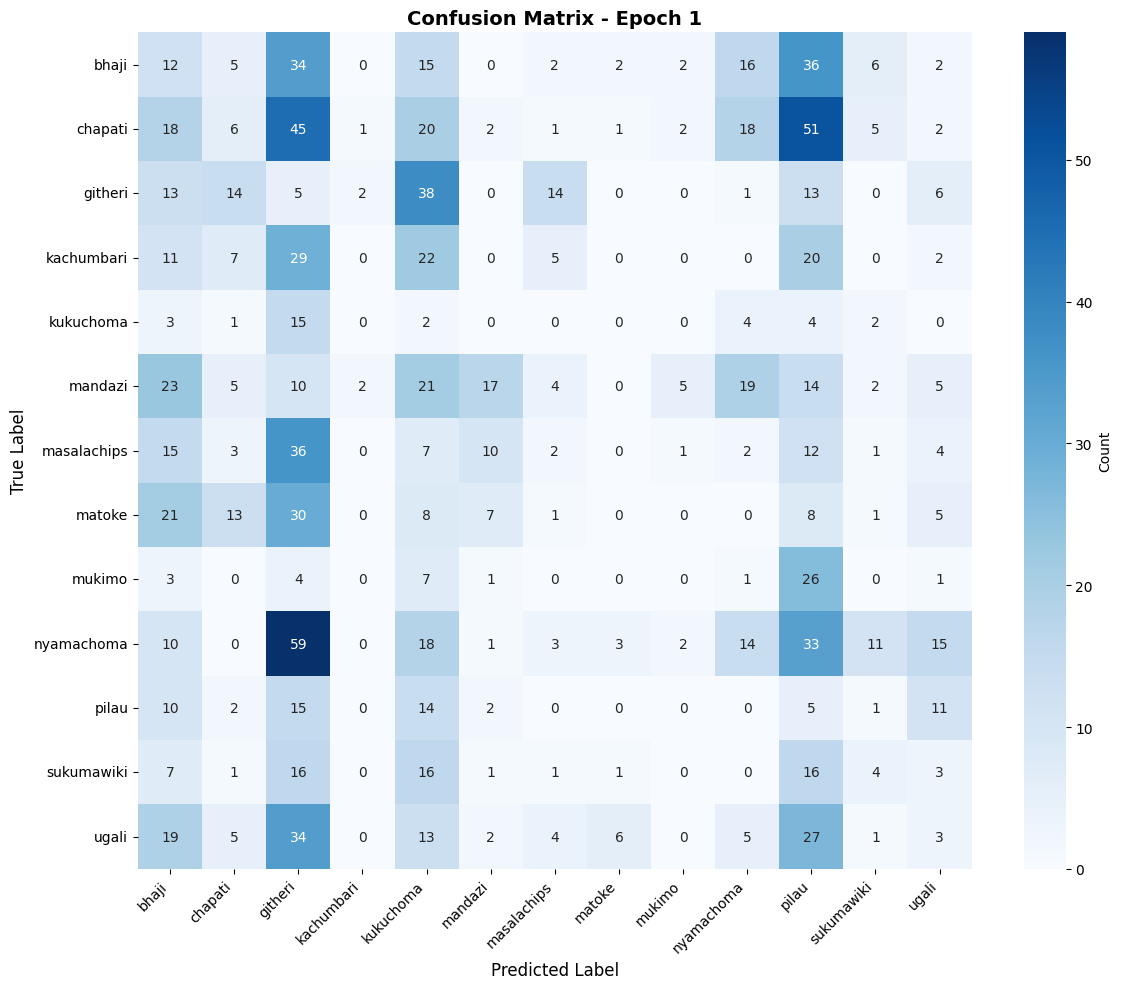

Confusion matrix saved to: confusion_matrices/conf_matrix_epoch_1.png

✨ Validation LOSS improved to: 2.6043
✨ Validation ACCURACY improved to: 0.0535
Saving best model...
Done.




Valid:	Epoch: 2/120	Loss: 2.5350, Acc: 0.0772: 100%|██████████| 41/41 [00:11<00:00,  3.45it/s]



Train Loss: 1.5936    Train Acc: 0.6134
Val Loss: 2.5350      Val Acc: 0.0772
Current Learning Rate: 0.0004


✨ Validation LOSS improved to: 2.5350
✨ Validation ACCURACY improved to: 0.0772
Saving best model...
Done.




Valid:	Epoch: 3/120	Loss: 2.4644, Acc: 0.1223: 100%|██████████| 41/41 [00:12<00:00,  3.37it/s]



Train Loss: 1.5485    Train Acc: 0.6339
Val Loss: 2.4644      Val Acc: 0.1223
Current Learning Rate: 0.0006


✨ Validation LOSS improved to: 2.4644
✨ Validation ACCURACY improved to: 0.1223
Saving best model...
Done.




Valid:	Epoch: 4/120	Loss: 2.3930, Acc: 0.2034: 100%|██████████| 41/41 [00:12<00:00,  3.27it/s]



Train Loss: 1.4979    Train Acc: 0.6646
Val Loss: 2.3930      Val Acc: 0.2034
Current Learning Rate: 0.0008


✨ Validation LOSS improved to: 2.3930
✨ Validation ACCURACY improved to: 0.2034
Saving best model...
Done.




Valid:	Epoch: 5/120	Loss: 2.3196, Acc: 0.2875: 100%|██████████| 41/41 [00:12<00:00,  3.39it/s]



Train Loss: 1.4397    Train Acc: 0.6927
Val Loss: 2.3196      Val Acc: 0.2875
Current Learning Rate: 0.001



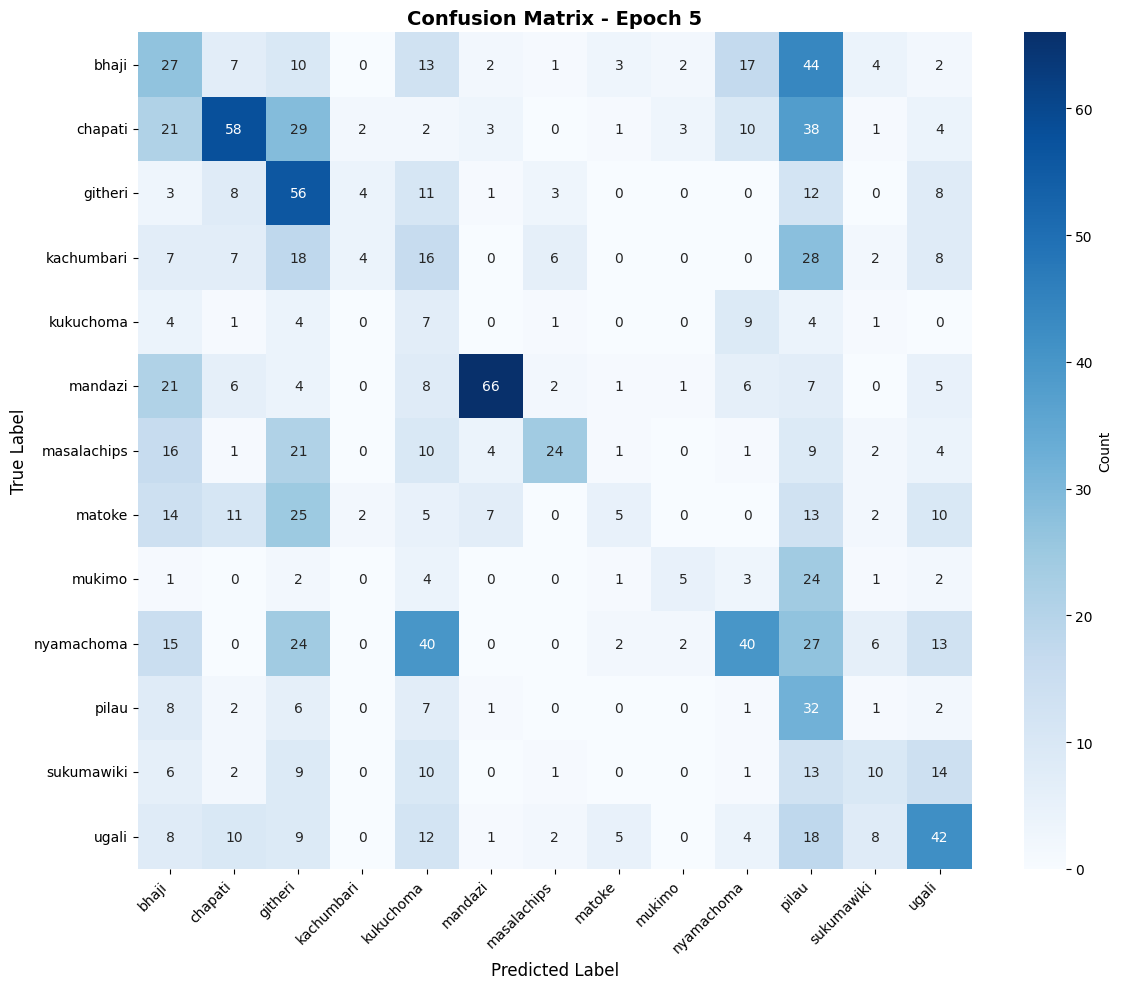

Confusion matrix saved to: confusion_matrices/conf_matrix_epoch_5.png

✨ Validation LOSS improved to: 2.3196
✨ Validation ACCURACY improved to: 0.2875
Saving best model...
Done.




Valid:	Epoch: 6/120	Loss: 2.2459, Acc: 0.3670: 100%|██████████| 41/41 [00:12<00:00,  3.39it/s]



Train Loss: 1.4062    Train Acc: 0.7065
Val Loss: 2.2459      Val Acc: 0.3670
Current Learning Rate: 0.0009998288338252908


✨ Validation LOSS improved to: 2.2459
✨ Validation ACCURACY improved to: 0.3670
Saving best model...
Done.




Valid:	Epoch: 7/120	Loss: 2.1729, Acc: 0.4373: 100%|██████████| 41/41 [00:12<00:00,  3.30it/s]



Train Loss: 1.4234    Train Acc: 0.7075
Val Loss: 2.1729      Val Acc: 0.4373
Current Learning Rate: 0.0009993154526099096


✨ Validation LOSS improved to: 2.1729
✨ Validation ACCURACY improved to: 0.4373
Saving best model...
Done.




...


Train Loss: 1.3720    Train Acc: 0.7301
Val Loss: 2.1000      Val Acc: 0.4992
Current Learning Rate: 0.0009984602081996976


✨ Validation LOSS improved to: 2.1000
✨ Validation ACCURACY improved to: 0.4992
Saving best model...
Done.



UNFREEZING: Stage 3 (features[3]) | LR: 1e-4



Valid:	Epoch: 9/120	Loss: 2.0279, Acc: 0.5474: 100%|██████████| 41/41 [00:12<00:00,  3.34it/s]



Train Loss: 1.3647    Train Acc: 0.7277
Val Loss: 2.0279      Val Acc: 0.5474
Current Learning Rate: 0.0009972636867364526


✨ Validation LOSS improved to: 2.0279
✨ Validation ACCURACY improved to: 0.5474
Saving best model...
Done.




Valid:	Epoch: 10/120	Loss: 1.9585, Acc: 0.5719: 100%|██████████| 41/41 [00:12<00:00,  3.40it/s]



Train Loss: 1.3463    Train Acc: 0.7424
Val Loss: 1.9585      Val Acc: 0.5719
Current Learning Rate: 0.0009957267082562184



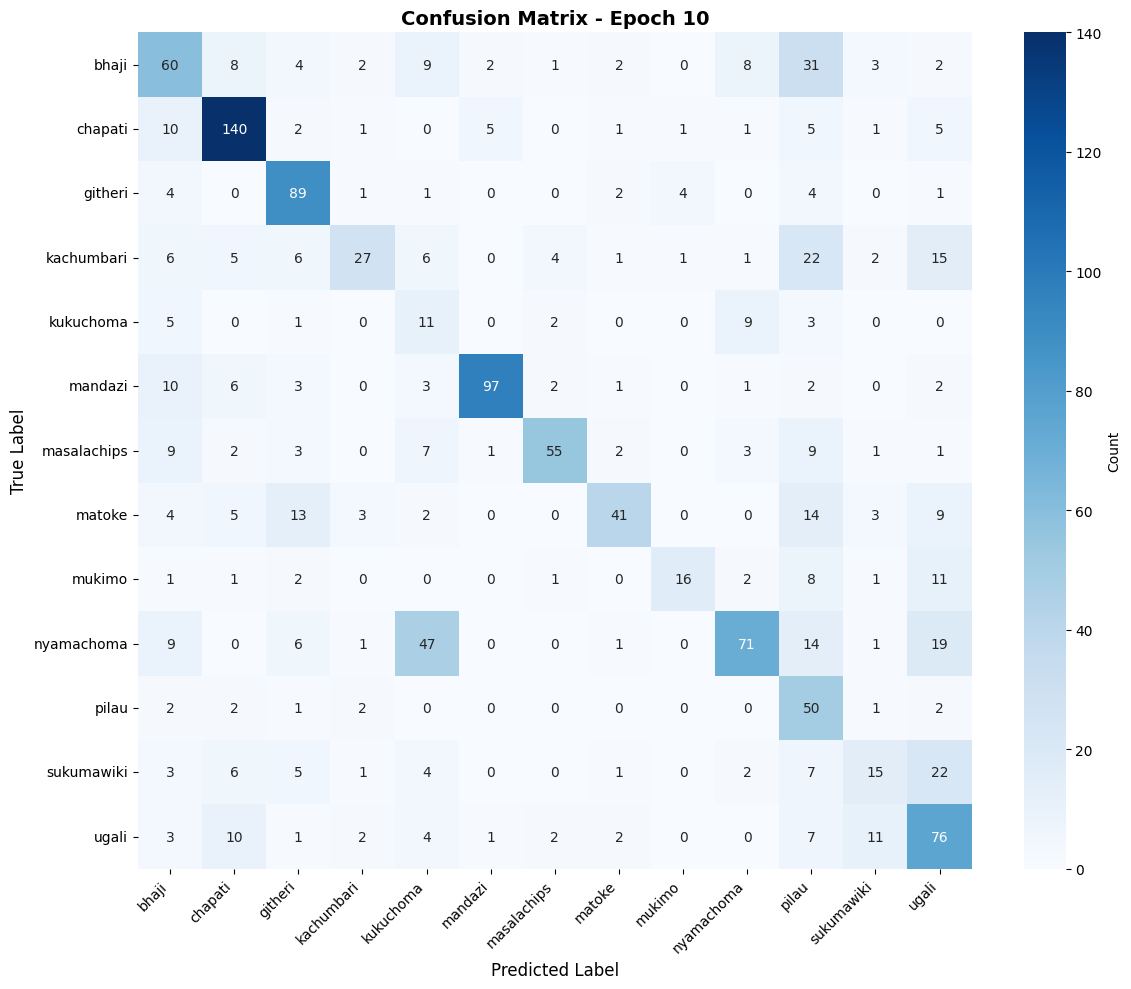

Confusion matrix saved to: confusion_matrices/conf_matrix_epoch_10.png

✨ Validation LOSS improved to: 1.9585
✨ Validation ACCURACY improved to: 0.5719
Saving best model...
Done.




Valid:	Epoch: 11/120	Loss: 1.8908, Acc: 0.5940: 100%|██████████| 41/41 [00:11<00:00,  3.42it/s]



Train Loss: 1.3124    Train Acc: 0.7531
Val Loss: 1.8908      Val Acc: 0.5940
Current Learning Rate: 0.0009938503261272714


✨ Validation LOSS improved to: 1.8908
✨ Validation ACCURACY improved to: 0.5940
Saving best model...
Done.




Valid:	Epoch: 12/120	Loss: 1.8249, Acc: 0.6177: 100%|██████████| 41/41 [00:12<00:00,  3.39it/s]



Train Loss: 1.3214    Train Acc: 0.7471
Val Loss: 1.8249      Val Acc: 0.6177
Current Learning Rate: 0.0009916358263281954


✨ Validation LOSS improved to: 1.8249
✨ Validation ACCURACY improved to: 0.6177
Saving best model...
Done.




...


Train Loss: 1.2790    Train Acc: 0.7678
Val Loss: 1.7613      Val Acc: 0.6437
Current Learning Rate: 0.000989084726566536


✨ Validation LOSS improved to: 1.7613
✨ Validation ACCURACY improved to: 0.6437
Saving best model...
Done.




Valid:	Epoch: 14/120	Loss: 1.6998, Acc: 0.6583: 100%|██████████| 41/41 [00:12<00:00,  3.40it/s]



Train Loss: 1.2643    Train Acc: 0.7765
Val Loss: 1.6998      Val Acc: 0.6583
Current Learning Rate: 0.0009861987752386395


✨ Validation LOSS improved to: 1.6998
✨ Validation ACCURACY improved to: 0.6583
Saving best model...
Done.




Valid:	Epoch: 15/120	Loss: 1.6418, Acc: 0.6743: 100%|██████████| 41/41 [00:11<00:00,  3.43it/s]



Train Loss: 1.2677    Train Acc: 0.7824
Val Loss: 1.6418      Val Acc: 0.6743
Current Learning Rate: 0.0009829799502313896



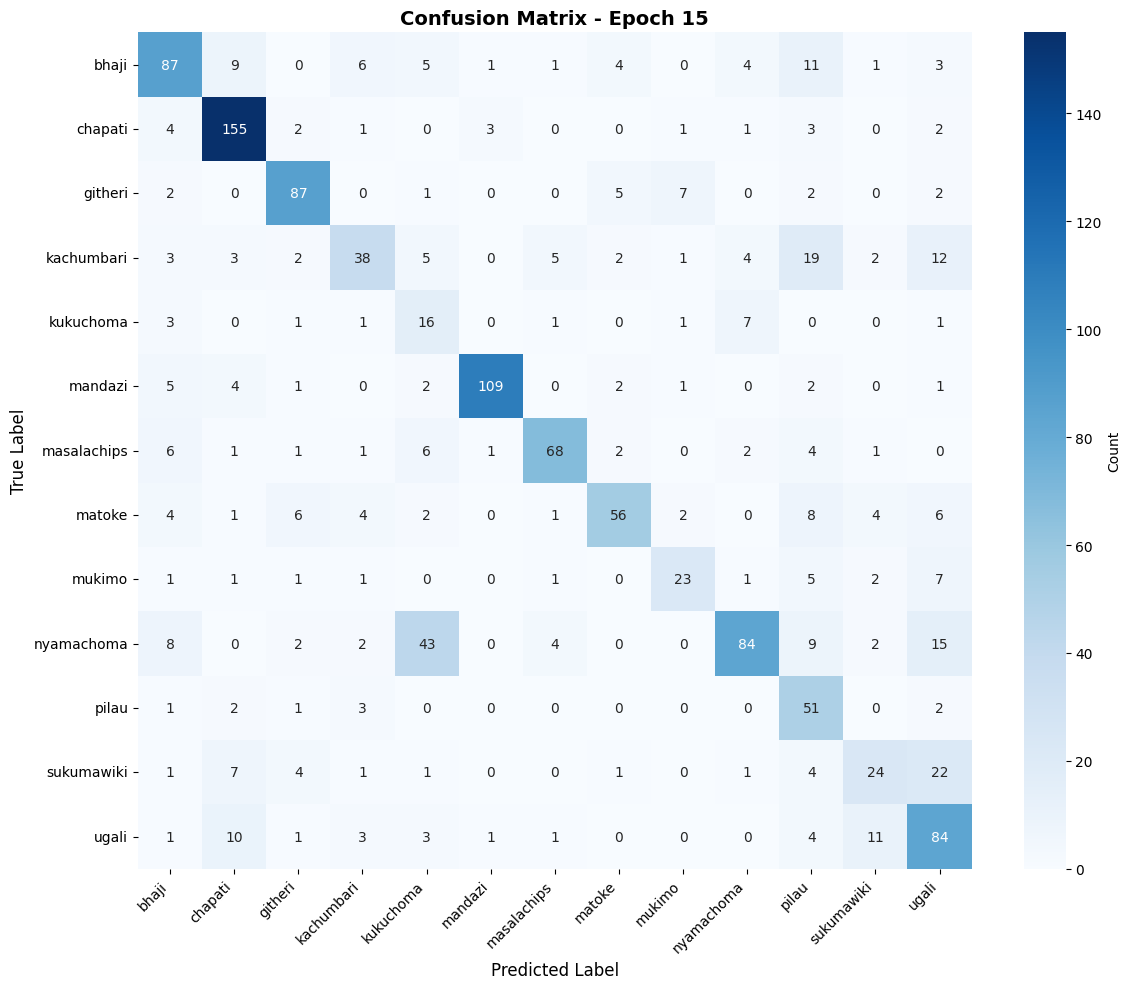

Confusion matrix saved to: confusion_matrices/conf_matrix_epoch_15.png

✨ Validation LOSS improved to: 1.6418
✨ Validation ACCURACY improved to: 0.6743
Saving best model...
Done.



UNFREEZING: Stage 2 (features[2]) | LR: 5e-5



Valid:	Epoch: 16/120	Loss: 1.5855, Acc: 0.6820: 100%|██████████| 41/41 [00:11<00:00,  3.47it/s]



Train Loss: 1.2406    Train Acc: 0.7966
Val Loss: 1.5855      Val Acc: 0.6820
Current Learning Rate: 0.0009794304575666624


✨ Validation LOSS improved to: 1.5855
✨ Validation ACCURACY improved to: 0.6820
Saving best model...
Done.




Valid:	Epoch: 17/120	Loss: 1.5314, Acc: 0.6919: 100%|██████████| 41/41 [00:12<00:00,  3.39it/s]



Train Loss: 1.2418    Train Acc: 0.7921
Val Loss: 1.5314      Val Acc: 0.6919
Current Learning Rate: 0.0009755527298894293


✨ Validation LOSS improved to: 1.5314
✨ Validation ACCURACY improved to: 0.6919
Saving best model...
Done.




...


Train Loss: 1.2308    Train Acc: 0.8009
Val Loss: 1.4794      Val Acc: 0.6972
Current Learning Rate: 0.0009713494248005432


✨ Validation LOSS improved to: 1.4794
✨ Validation ACCURACY improved to: 0.6972
Saving best model...
Done.




Valid:	Epoch: 19/120	Loss: 1.4308, Acc: 0.7049: 100%|██████████| 41/41 [00:12<00:00,  3.38it/s]



Train Loss: 1.2202    Train Acc: 0.8104
Val Loss: 1.4308      Val Acc: 0.7049
Current Learning Rate: 0.0009668234230353522


✨ Validation LOSS improved to: 1.4308
✨ Validation ACCURACY improved to: 0.7049
Saving best model...
Done.




Valid:	Epoch: 20/120	Loss: 1.3850, Acc: 0.7087: 100%|██████████| 41/41 [00:11<00:00,  3.42it/s]



Train Loss: 1.1919    Train Acc: 0.8173
Val Loss: 1.3850      Val Acc: 0.7087
Current Learning Rate: 0.0009619778264893877



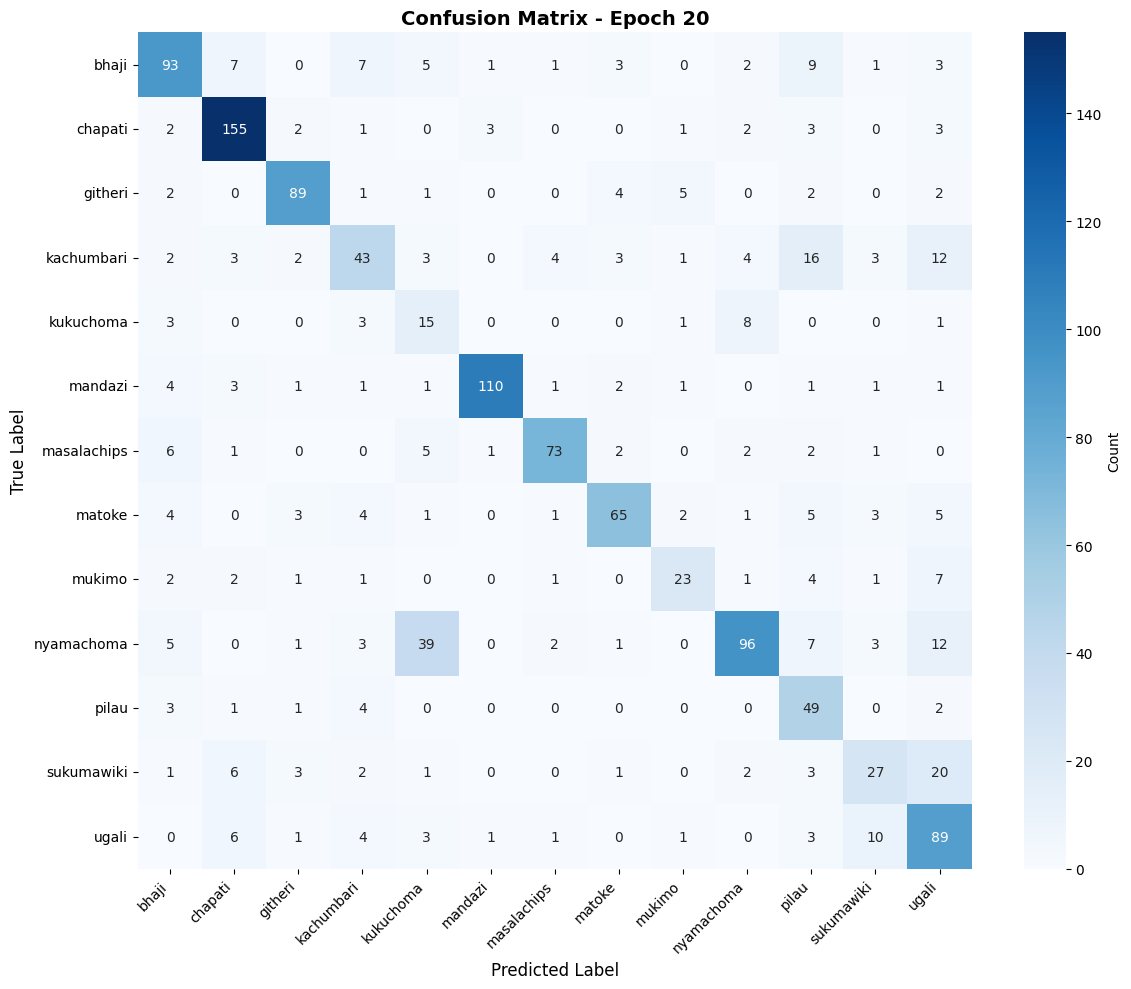

Confusion matrix saved to: confusion_matrices/conf_matrix_epoch_20.png

✨ Validation LOSS improved to: 1.3850
✨ Validation ACCURACY improved to: 0.7087
Saving best model...
Done.



UNFREEZING: Stage 1 + Stem | LR: 1e-5



Valid:	Epoch: 21/120	Loss: 1.3418, Acc: 0.7141: 100%|██████████| 41/41 [00:12<00:00,  3.38it/s]



Train Loss: 1.2077    Train Acc: 0.8074
Val Loss: 1.3418      Val Acc: 0.7141
Current Learning Rate: 0.000956815956092479


✨ Validation LOSS improved to: 1.3418
✨ Validation ACCURACY improved to: 0.7141
Saving best model...
Done.




Valid:	Epoch: 22/120	Loss: 1.3010, Acc: 0.7141: 100%|██████████| 41/41 [00:11<00:00,  3.44it/s]



Train Loss: 1.1749    Train Acc: 0.8306
Val Loss: 1.3010      Val Acc: 0.7141
Current Learning Rate: 0.0009513413495327554


✨ Validation LOSS improved to: 1.3010
Saving best model...
Done.




...


Train Loss: 1.1648    Train Acc: 0.8314
Val Loss: 1.2622      Val Acc: 0.7156
Current Learning Rate: 0.0009455577588320897


✨ Validation LOSS improved to: 1.2622
✨ Validation ACCURACY improved to: 0.7156
Saving best model...
Done.




Valid:	Epoch: 24/120	Loss: 1.2262, Acc: 0.7179: 100%|██████████| 41/41 [00:12<00:00,  3.36it/s]



Train Loss: 1.1640    Train Acc: 0.8320
Val Loss: 1.2262      Val Acc: 0.7179
Current Learning Rate: 0.0009394691477746516


✨ Validation LOSS improved to: 1.2262
✨ Validation ACCURACY improved to: 0.7179
Saving best model...
Done.




Valid:	Epoch: 25/120	Loss: 1.1918, Acc: 0.7232: 100%|██████████| 41/41 [00:12<00:00,  3.39it/s]



Train Loss: 1.1474    Train Acc: 0.8402
Val Loss: 1.1918      Val Acc: 0.7232
Current Learning Rate: 0.0009330796891903272



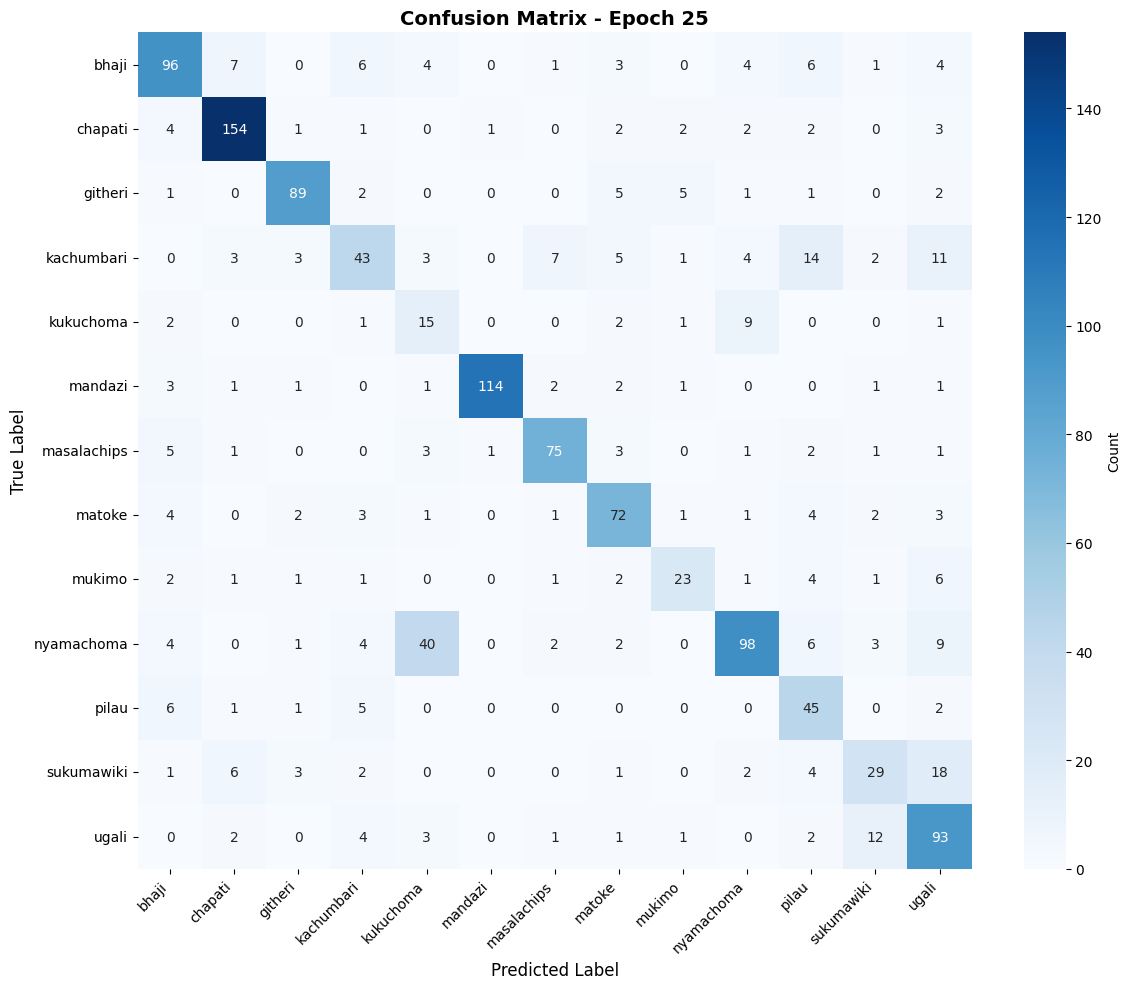

Confusion matrix saved to: confusion_matrices/conf_matrix_epoch_25.png

✨ Validation LOSS improved to: 1.1918
✨ Validation ACCURACY improved to: 0.7232
Saving best model...
Done.




Valid:	Epoch: 26/120	Loss: 1.1596, Acc: 0.7309: 100%|██████████| 41/41 [00:12<00:00,  3.35it/s]



Train Loss: 1.1596    Train Acc: 0.8372
Val Loss: 1.1596      Val Acc: 0.7309
Current Learning Rate: 0.000926393762094869


✨ Validation LOSS improved to: 1.1596
✨ Validation ACCURACY improved to: 0.7309
Saving best model...
Done.




Valid:	Epoch: 27/120	Loss: 1.1294, Acc: 0.7317: 100%|██████████| 41/41 [00:12<00:00,  3.41it/s]



Train Loss: 1.1481    Train Acc: 0.8414
Val Loss: 1.1294      Val Acc: 0.7317
Current Learning Rate: 0.0009194159486887393


✨ Validation LOSS improved to: 1.1294
✨ Validation ACCURACY improved to: 0.7317
Saving best model...
Done.




...


Train Loss: 1.1364    Train Acc: 0.8401
Val Loss: 1.1017      Val Acc: 0.7339
Current Learning Rate: 0.0009121510312166968


✨ Validation LOSS improved to: 1.1017
✨ Validation ACCURACY improved to: 0.7339
Saving best model...
Done.




Valid:	Epoch: 29/120	Loss: 1.0749, Acc: 0.7355: 100%|██████████| 41/41 [00:12<00:00,  3.31it/s]



Train Loss: 1.1184    Train Acc: 0.8598
Val Loss: 1.0749      Val Acc: 0.7355
Current Learning Rate: 0.0009046039886902862


✨ Validation LOSS improved to: 1.0749
✨ Validation ACCURACY improved to: 0.7355
Saving best model...
Done.




Valid:	Epoch: 30/120	Loss: 1.0500, Acc: 0.7347: 100%|██████████| 41/41 [00:11<00:00,  3.43it/s]



Train Loss: 1.1034    Train Acc: 0.8581
Val Loss: 1.0500      Val Acc: 0.7347
Current Learning Rate: 0.0008967799934754719



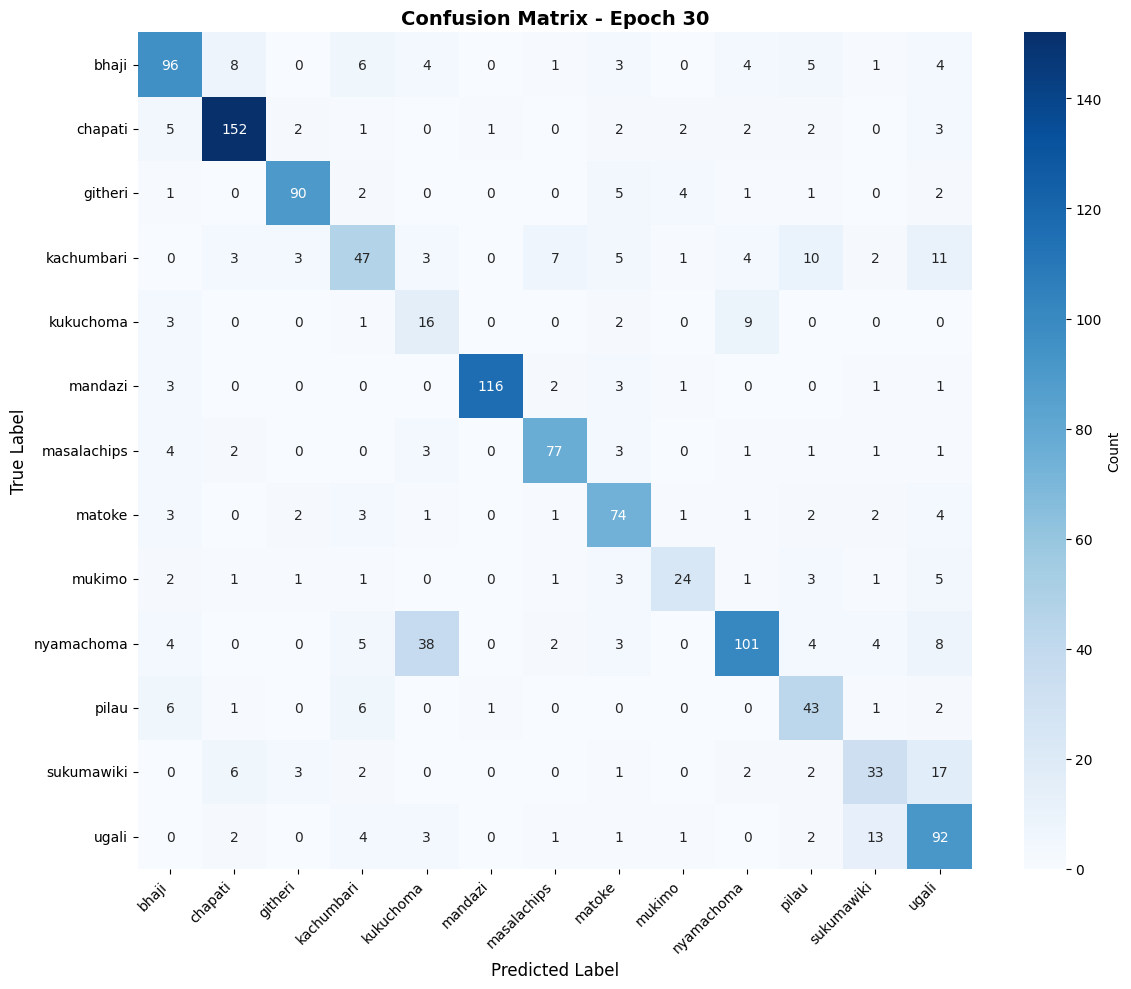

Confusion matrix saved to: confusion_matrices/conf_matrix_epoch_30.png

✨ Validation LOSS improved to: 1.0500
Saving best model...
Done.




Valid:	Epoch: 31/120	Loss: 1.0263, Acc: 0.7355: 100%|██████████| 41/41 [00:12<00:00,  3.32it/s]



Train Loss: 1.1212    Train Acc: 0.8574
Val Loss: 1.0263      Val Acc: 0.7355
Current Learning Rate: 0.0008886844077477569


✨ Validation LOSS improved to: 1.0263
Saving best model...
Done.




Valid:	Epoch: 32/120	Loss: 1.0046, Acc: 0.7370: 100%|██████████| 41/41 [00:12<00:00,  3.40it/s]



Train Loss: 1.1121    Train Acc: 0.8671
Val Loss: 1.0046      Val Acc: 0.7370
Current Learning Rate: 0.0008803227798172155


✨ Validation LOSS improved to: 1.0046
✨ Validation ACCURACY improved to: 0.7370
Saving best model...
Done.




...


Train Loss: 1.0910    Train Acc: 0.8685
Val Loss: 0.9843      Val Acc: 0.7401
Current Learning Rate: 0.0008717008403259584


✨ Validation LOSS improved to: 0.9843
✨ Validation ACCURACY improved to: 0.7401
Saving best model...
Done.




Valid:	Epoch: 34/120	Loss: 0.9649, Acc: 0.7401: 100%|██████████| 41/41 [00:12<00:00,  3.31it/s]



Train Loss: 1.1084    Train Acc: 0.8600
Val Loss: 0.9649      Val Acc: 0.7401
Current Learning Rate: 0.0008628244983206376


✨ Validation LOSS improved to: 0.9649
Saving best model...
Done.




Valid:	Epoch: 35/120	Loss: 0.9468, Acc: 0.7454: 100%|██████████| 41/41 [00:12<00:00,  3.36it/s]



Train Loss: 1.0831    Train Acc: 0.8720
Val Loss: 0.9468      Val Acc: 0.7454
Current Learning Rate: 0.0008536998372026804



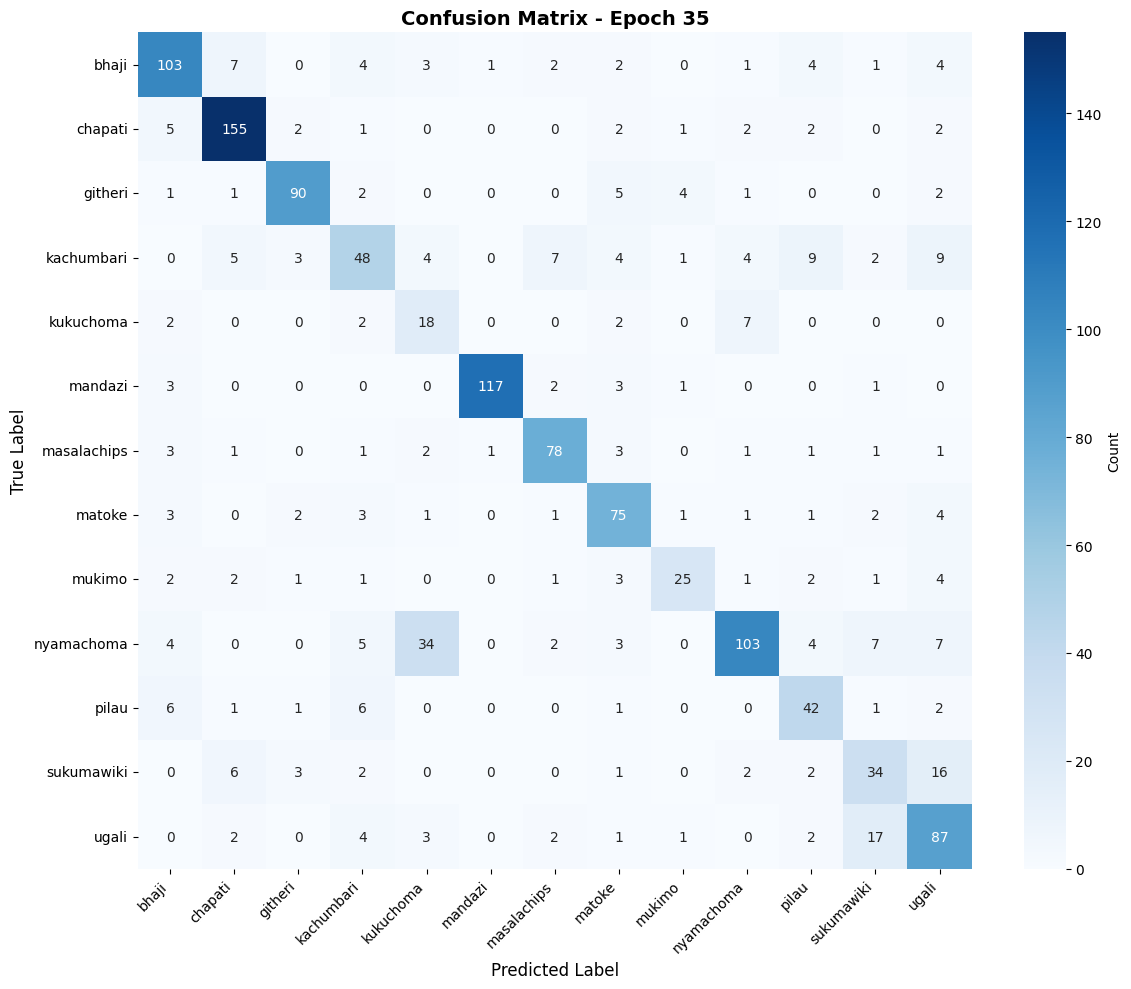

Confusion matrix saved to: confusion_matrices/conf_matrix_epoch_35.png

✨ Validation LOSS improved to: 0.9468
✨ Validation ACCURACY improved to: 0.7454
Saving best model...
Done.




Valid:	Epoch: 36/120	Loss: 0.9299, Acc: 0.7462: 100%|██████████| 41/41 [00:12<00:00,  3.35it/s]



Train Loss: 1.0758    Train Acc: 0.8722
Val Loss: 0.9299      Val Acc: 0.7462
Current Learning Rate: 0.00084433311055903


✨ Validation LOSS improved to: 0.9299
✨ Validation ACCURACY improved to: 0.7462
Saving best model...
Done.




Valid:	Epoch: 37/120	Loss: 0.9143, Acc: 0.7462: 100%|██████████| 41/41 [00:11<00:00,  3.45it/s]



Train Loss: 1.0758    Train Acc: 0.8772
Val Loss: 0.9143      Val Acc: 0.7462
Current Learning Rate: 0.0008347307378762496


✨ Validation LOSS improved to: 0.9143
Saving best model...
Done.




...


Train Loss: 1.0722    Train Acc: 0.8738
Val Loss: 0.8998      Val Acc: 0.7477
Current Learning Rate: 0.0008248993001409267


✨ Validation LOSS improved to: 0.8998
✨ Validation ACCURACY improved to: 0.7477
Saving best model...
Done.




Valid:	Epoch: 39/120	Loss: 0.8861, Acc: 0.7485: 100%|██████████| 41/41 [00:12<00:00,  3.41it/s]



Train Loss: 1.0753    Train Acc: 0.8691
Val Loss: 0.8861      Val Acc: 0.7485
Current Learning Rate: 0.0008148455353293938


✨ Validation LOSS improved to: 0.8861
✨ Validation ACCURACY improved to: 0.7485
Saving best model...
Done.




Valid:	Epoch: 40/120	Loss: 0.8734, Acc: 0.7492: 100%|██████████| 41/41 [00:12<00:00,  3.39it/s]



Train Loss: 1.0476    Train Acc: 0.8877
Val Loss: 0.8734      Val Acc: 0.7492
Current Learning Rate: 0.000804576333789856



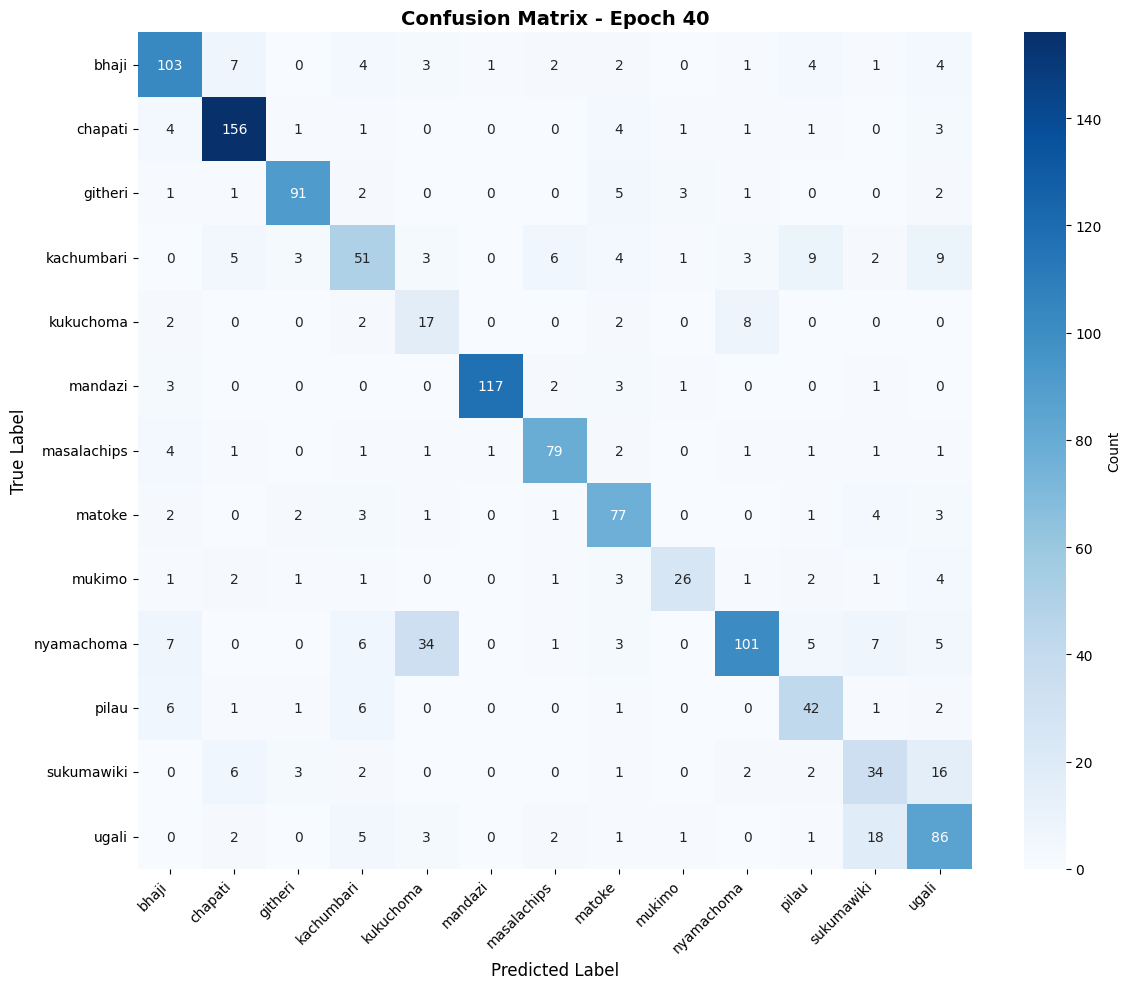

Confusion matrix saved to: confusion_matrices/conf_matrix_epoch_40.png

✨ Validation LOSS improved to: 0.8734
✨ Validation ACCURACY improved to: 0.7492
Saving best model...
Done.




Valid:	Epoch: 41/120	Loss: 0.8617, Acc: 0.7546: 100%|██████████| 41/41 [00:11<00:00,  3.45it/s]



Train Loss: 1.0556    Train Acc: 0.8826
Val Loss: 0.8617      Val Acc: 0.7546
Current Learning Rate: 0.0007940987335200904


✨ Validation LOSS improved to: 0.8617
✨ Validation ACCURACY improved to: 0.7546
Saving best model...
Done.




Valid:	Epoch: 42/120	Loss: 0.8511, Acc: 0.7546: 100%|██████████| 41/41 [00:11<00:00,  3.45it/s]



Train Loss: 1.0509    Train Acc: 0.8839
Val Loss: 0.8511      Val Acc: 0.7546
Current Learning Rate: 0.000783419915343954


✨ Validation LOSS improved to: 0.8511
Saving best model...
Done.




...


Train Loss: 1.0515    Train Acc: 0.8868
Val Loss: 0.8411      Val Acc: 0.7576
Current Learning Rate: 0.0007725471979900061


✨ Validation LOSS improved to: 0.8411
✨ Validation ACCURACY improved to: 0.7576
Saving best model...
Done.




Valid:	Epoch: 44/120	Loss: 0.8316, Acc: 0.7554: 100%|██████████| 41/41 [00:12<00:00,  3.38it/s]



Train Loss: 1.0386    Train Acc: 0.8875
Val Loss: 0.8316      Val Acc: 0.7554
Current Learning Rate: 0.0007614880330756164


✨ Validation LOSS improved to: 0.8316
Saving best model...
Done.




Valid:	Epoch: 45/120	Loss: 0.8228, Acc: 0.7576: 100%|██████████| 41/41 [00:12<00:00,  3.40it/s]



Train Loss: 1.0298    Train Acc: 0.8963
Val Loss: 0.8228      Val Acc: 0.7576
Current Learning Rate: 0.0007502499999999999



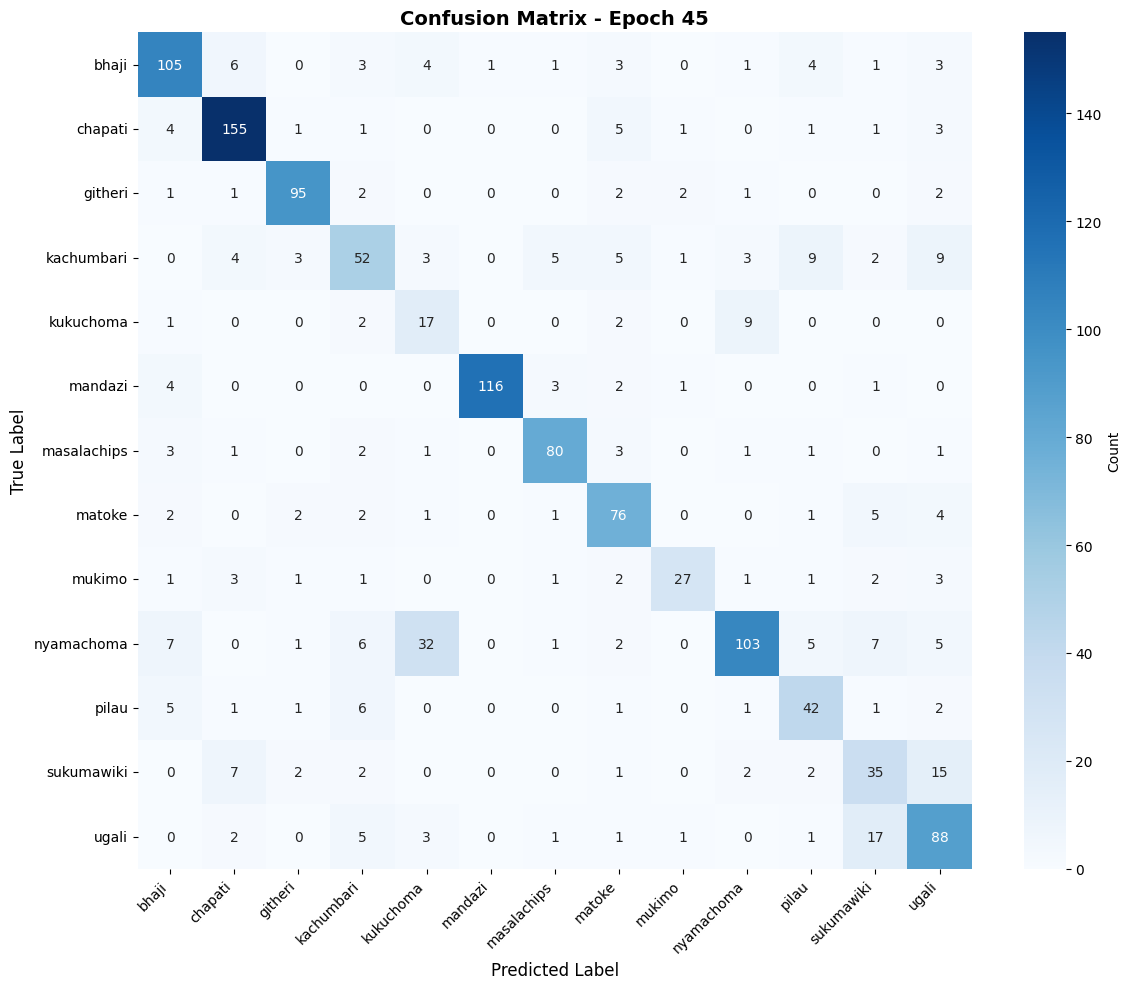

Confusion matrix saved to: confusion_matrices/conf_matrix_epoch_45.png

✨ Validation LOSS improved to: 0.8228
Saving best model...
Done.




Valid:	Epoch: 46/120	Loss: 0.8142, Acc: 0.7576: 100%|██████████| 41/41 [00:12<00:00,  3.37it/s]



Train Loss: 1.0145    Train Acc: 0.8965
Val Loss: 0.8142      Val Acc: 0.7576
Current Learning Rate: 0.0007388408007496744


✨ Validation LOSS improved to: 0.8142
Saving best model...
Done.




Valid:	Epoch: 47/120	Loss: 0.8065, Acc: 0.7546: 100%|██████████| 41/41 [00:12<00:00,  3.29it/s]



Train Loss: 1.0113    Train Acc: 0.9034
Val Loss: 0.8065      Val Acc: 0.7546
Current Learning Rate: 0.0007272682546199035


✨ Validation LOSS improved to: 0.8065
Saving best model...
Done.




...


Train Loss: 1.0153    Train Acc: 0.9024
Val Loss: 0.7992      Val Acc: 0.7538
Current Learning Rate: 0.0007155402928557433


✨ Validation LOSS improved to: 0.7992
Saving best model...
Done.




Valid:	Epoch: 49/120	Loss: 0.7923, Acc: 0.7554: 100%|██████████| 41/41 [00:12<00:00,  3.36it/s]



Train Loss: 1.0133    Train Acc: 0.9023
Val Loss: 0.7923      Val Acc: 0.7554
Current Learning Rate: 0.0007036649532163621


✨ Validation LOSS improved to: 0.7923
Saving best model...
Done.




Valid:	Epoch: 50/120	Loss: 0.7857, Acc: 0.7576: 100%|██████████| 41/41 [00:12<00:00,  3.35it/s]



Train Loss: 1.0195    Train Acc: 0.9005
Val Loss: 0.7857      Val Acc: 0.7576
Current Learning Rate: 0.0006916503744663621



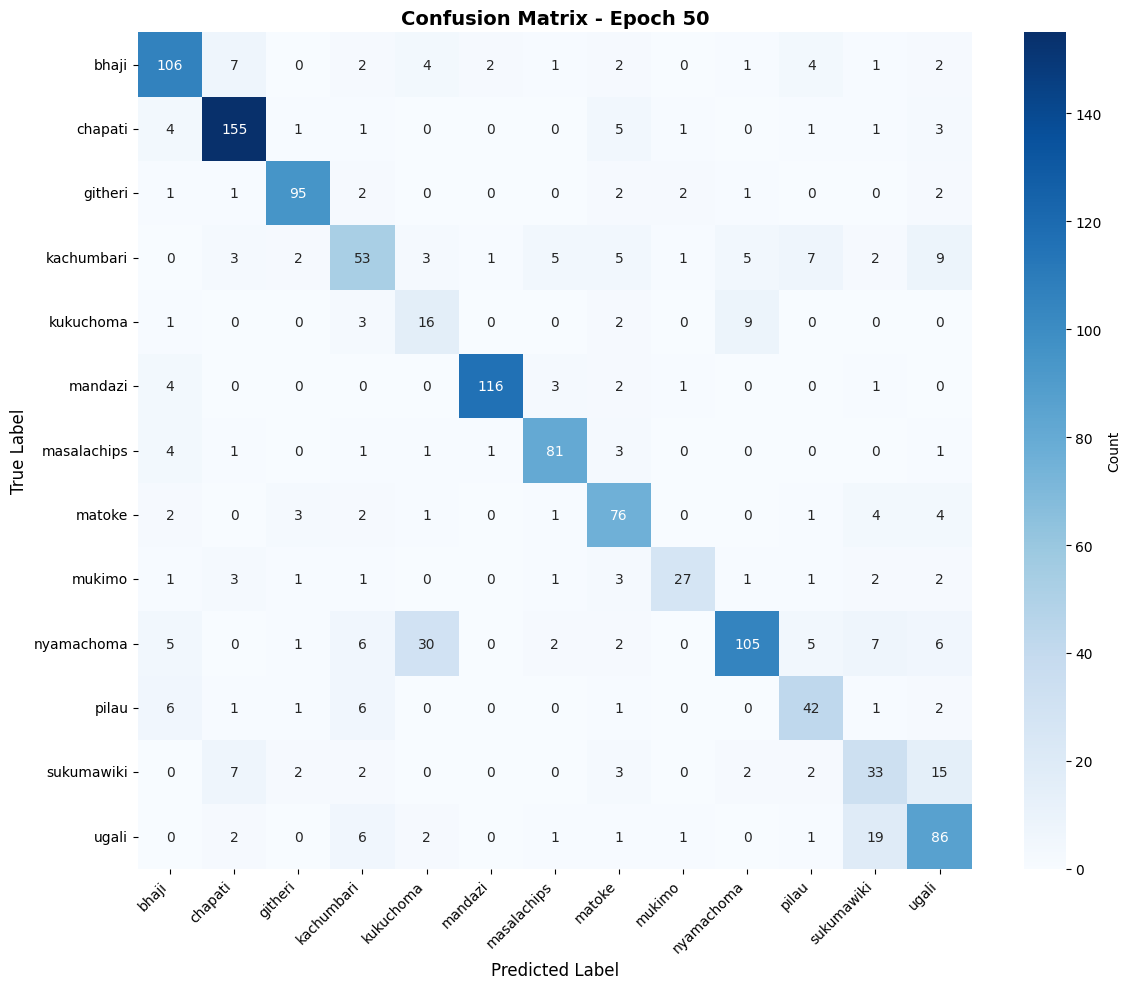

Confusion matrix saved to: confusion_matrices/conf_matrix_epoch_50.png

✨ Validation LOSS improved to: 0.7857
Saving best model...
Done.




Valid:	Epoch: 51/120	Loss: 0.7796, Acc: 0.7592: 100%|██████████| 41/41 [00:12<00:00,  3.41it/s]



Train Loss: 1.0118    Train Acc: 0.9015
Val Loss: 0.7796      Val Acc: 0.7592
Current Learning Rate: 0.0006795047907978774


✨ Validation LOSS improved to: 0.7796
✨ Validation ACCURACY improved to: 0.7592
Saving best model...
Done.




Valid:	Epoch: 52/120	Loss: 0.7744, Acc: 0.7599: 100%|██████████| 41/41 [00:12<00:00,  3.38it/s]



Train Loss: 0.9923    Train Acc: 0.9095
Val Loss: 0.7744      Val Acc: 0.7599
Current Learning Rate: 0.0006672365261872684


✨ Validation LOSS improved to: 0.7744
✨ Validation ACCURACY improved to: 0.7599
Saving best model...
Done.




...


Train Loss: 1.0015    Train Acc: 0.9068
Val Loss: 0.7695      Val Acc: 0.7599
Current Learning Rate: 0.0006548539886902862


✨ Validation LOSS improved to: 0.7695
Saving best model...
Done.




Valid:	Epoch: 54/120	Loss: 0.7649, Acc: 0.7599: 100%|██████████| 41/41 [00:12<00:00,  3.36it/s]



Train Loss: 0.9909    Train Acc: 0.9151
Val Loss: 0.7649      Val Acc: 0.7599
Current Learning Rate: 0.0006423656646796094


✨ Validation LOSS improved to: 0.7649
Saving best model...
Done.




Valid:	Epoch: 55/120	Loss: 0.7605, Acc: 0.7630: 100%|██████████| 41/41 [00:12<00:00,  3.29it/s]



Train Loss: 0.9870    Train Acc: 0.9151
Val Loss: 0.7605      Val Acc: 0.7630
Current Learning Rate: 0.000629780113028709



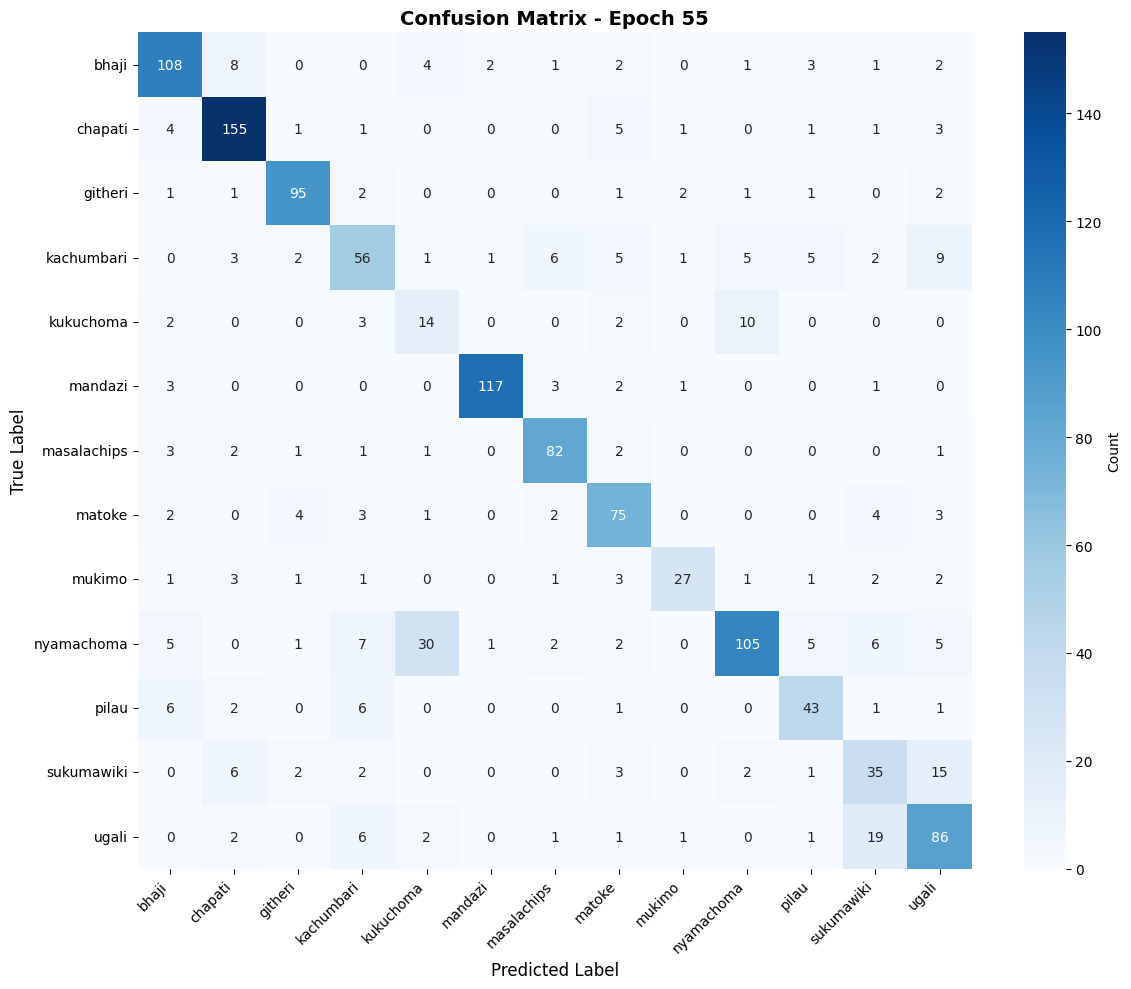

Confusion matrix saved to: confusion_matrices/conf_matrix_epoch_55.png

✨ Validation LOSS improved to: 0.7605
✨ Validation ACCURACY improved to: 0.7630
Saving best model...
Done.




Valid:	Epoch: 56/120	Loss: 0.7562, Acc: 0.7645: 100%|██████████| 41/41 [00:12<00:00,  3.39it/s]



Train Loss: 0.9885    Train Acc: 0.9134
Val Loss: 0.7562      Val Acc: 0.7645
Current Learning Rate: 0.0006171059592460247


✨ Validation LOSS improved to: 0.7562
✨ Validation ACCURACY improved to: 0.7645
Saving best model...
Done.




Valid:	Epoch: 57/120	Loss: 0.7524, Acc: 0.7645: 100%|██████████| 41/41 [00:12<00:00,  3.37it/s]



Train Loss: 0.9757    Train Acc: 0.9172
Val Loss: 0.7524      Val Acc: 0.7645
Current Learning Rate: 0.0006043518895634706


✨ Validation LOSS improved to: 0.7524
Saving best model...
Done.




...


Train Loss: 0.9729    Train Acc: 0.9199
Val Loss: 0.7488      Val Acc: 0.7661
Current Learning Rate: 0.0005915266449833275


✨ Validation LOSS improved to: 0.7488
✨ Validation ACCURACY improved to: 0.7661
Saving best model...
Done.




Valid:	Epoch: 59/120	Loss: 0.7452, Acc: 0.7676: 100%|██████████| 41/41 [00:12<00:00,  3.37it/s]



Train Loss: 0.9809    Train Acc: 0.9158
Val Loss: 0.7452      Val Acc: 0.7676
Current Learning Rate: 0.0005786390152875951


✨ Validation LOSS improved to: 0.7452
✨ Validation ACCURACY improved to: 0.7676
Saving best model...
Done.




Valid:	Epoch: 60/120	Loss: 0.7420, Acc: 0.7691: 100%|██████████| 41/41 [00:12<00:00,  3.38it/s]



Train Loss: 0.9676    Train Acc: 0.9193
Val Loss: 0.7420      Val Acc: 0.7691
Current Learning Rate: 0.0005656978330139155



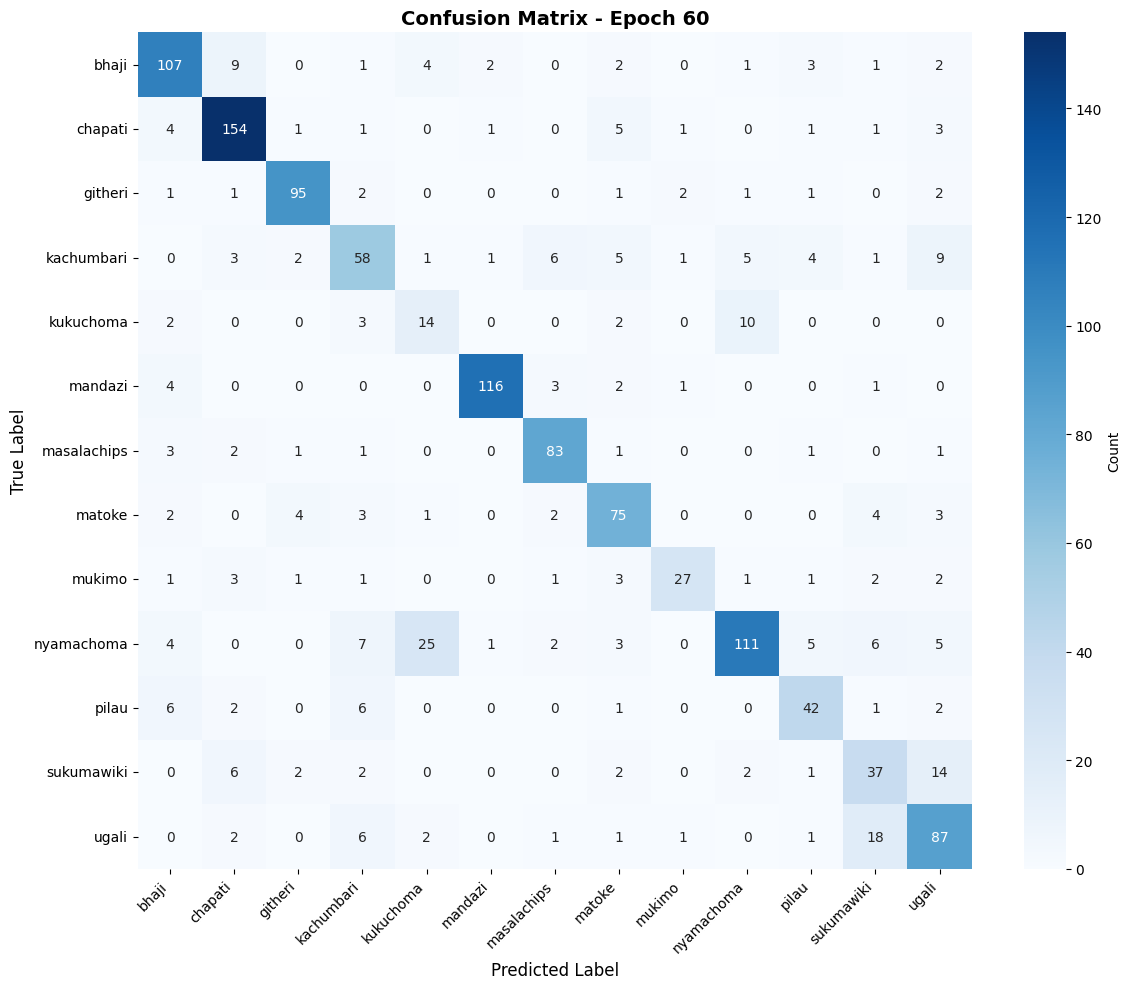

Confusion matrix saved to: confusion_matrices/conf_matrix_epoch_60.png

✨ Validation LOSS improved to: 0.7420
✨ Validation ACCURACY improved to: 0.7691
Saving best model...
Done.




Valid:	Epoch: 61/120	Loss: 0.7391, Acc: 0.7699: 100%|██████████| 41/41 [00:12<00:00,  3.39it/s]



Train Loss: 0.9648    Train Acc: 0.9229
Val Loss: 0.7391      Val Acc: 0.7699
Current Learning Rate: 0.0005527119674021928


✨ Validation LOSS improved to: 0.7391
✨ Validation ACCURACY improved to: 0.7699
Saving best model...
Done.




Valid:	Epoch: 62/120	Loss: 0.7362, Acc: 0.7691: 100%|██████████| 41/41 [00:12<00:00,  3.40it/s]



Train Loss: 0.9618    Train Acc: 0.9269
Val Loss: 0.7362      Val Acc: 0.7691
Current Learning Rate: 0.0005396903183160584


✨ Validation LOSS improved to: 0.7362
Saving best model...
Done.




...


Train Loss: 0.9586    Train Acc: 0.9258
Val Loss: 0.7333      Val Acc: 0.7699
Current Learning Rate: 0.0005266418101433502


✨ Validation LOSS improved to: 0.7333
Saving best model...
Done.




Valid:	Epoch: 64/120	Loss: 0.7308, Acc: 0.7683: 100%|██████████| 41/41 [00:12<00:00,  3.38it/s]



Train Loss: 0.9667    Train Acc: 0.9189
Val Loss: 0.7308      Val Acc: 0.7683
Current Learning Rate: 0.0005135753856797824


✨ Validation LOSS improved to: 0.7308
Saving best model...
Done.




Valid:	Epoch: 65/120	Loss: 0.7285, Acc: 0.7683: 100%|██████████| 41/41 [00:12<00:00,  3.36it/s]



Train Loss: 0.9454    Train Acc: 0.9348
Val Loss: 0.7285      Val Acc: 0.7683
Current Learning Rate: 0.0005005



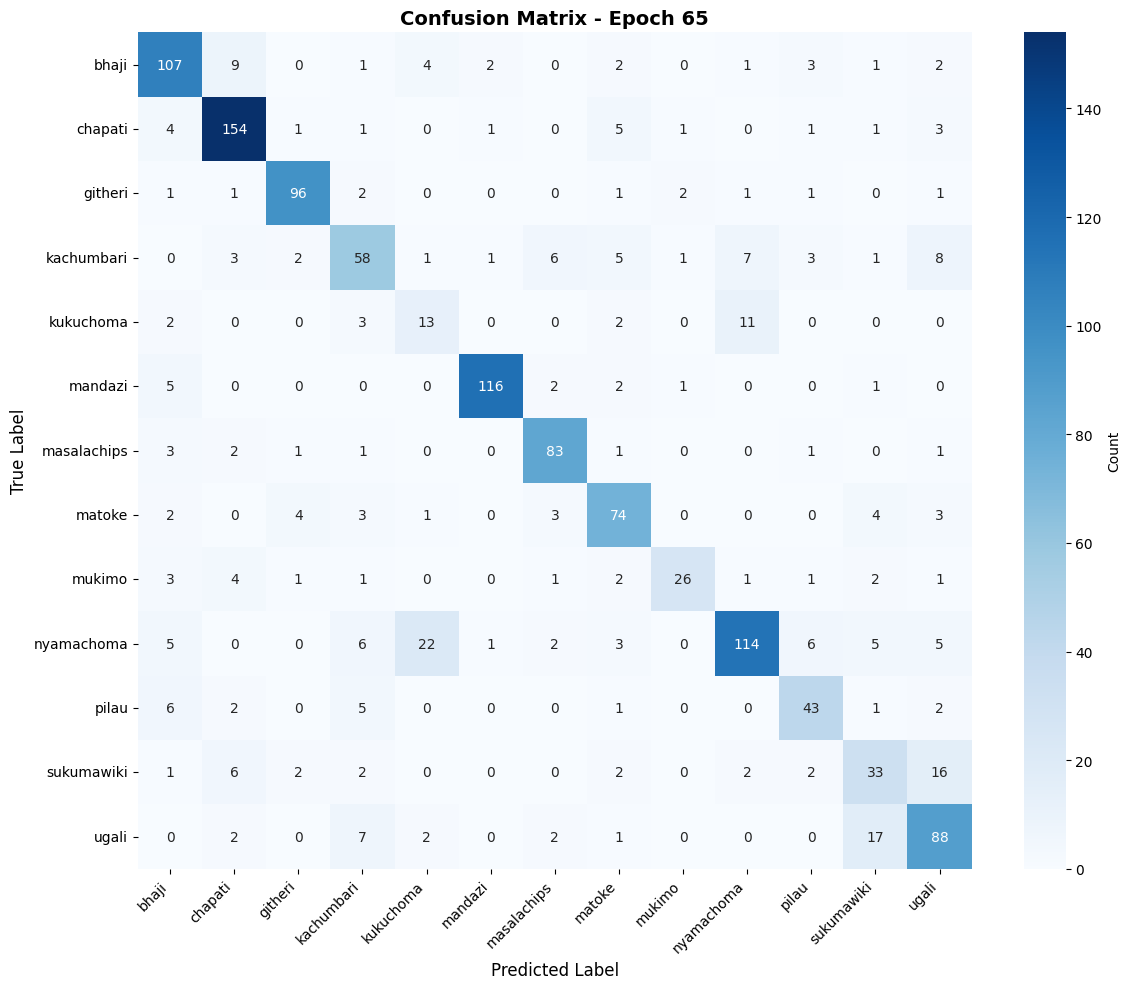

Confusion matrix saved to: confusion_matrices/conf_matrix_epoch_65.png

✨ Validation LOSS improved to: 0.7285
Saving best model...
Done.




Valid:	Epoch: 66/120	Loss: 0.7265, Acc: 0.7691: 100%|██████████| 41/41 [00:12<00:00,  3.33it/s]



Train Loss: 0.9412    Train Acc: 0.9359
Val Loss: 0.7265      Val Acc: 0.7691
Current Learning Rate: 0.0004874246143202173


✨ Validation LOSS improved to: 0.7265
Saving best model...
Done.




Valid:	Epoch: 67/120	Loss: 0.7241, Acc: 0.7683: 100%|██████████| 41/41 [00:12<00:00,  3.30it/s]



Train Loss: 0.9547    Train Acc: 0.9285
Val Loss: 0.7241      Val Acc: 0.7683
Current Learning Rate: 0.0004743581898566495


✨ Validation LOSS improved to: 0.7241
Saving best model...
Done.




...


Train Loss: 0.9403    Train Acc: 0.9373
Val Loss: 0.7221      Val Acc: 0.7691
Current Learning Rate: 0.0004613096816839414


✨ Validation LOSS improved to: 0.7221
Saving best model...
Done.




Valid:	Epoch: 69/120	Loss: 0.7199, Acc: 0.7699: 100%|██████████| 41/41 [00:12<00:00,  3.37it/s]



Train Loss: 0.9485    Train Acc: 0.9306
Val Loss: 0.7199      Val Acc: 0.7699
Current Learning Rate: 0.0004482880325978071


✨ Validation LOSS improved to: 0.7199
Saving best model...
Done.




Valid:	Epoch: 70/120	Loss: 0.7179, Acc: 0.7706: 100%|██████████| 41/41 [00:12<00:00,  3.29it/s]



Train Loss: 0.9513    Train Acc: 0.9267
Val Loss: 0.7179      Val Acc: 0.7706
Current Learning Rate: 0.00043530216698608424



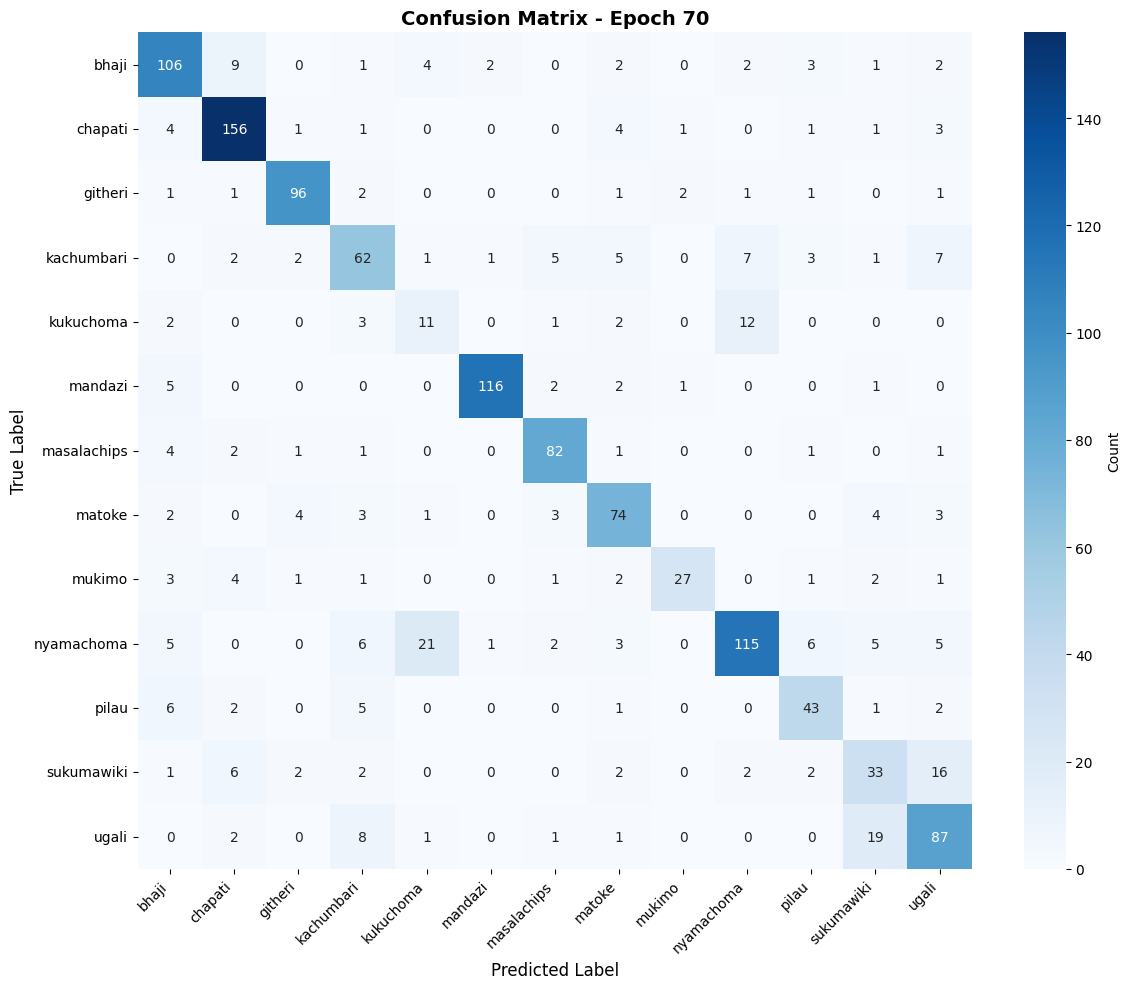

Confusion matrix saved to: confusion_matrices/conf_matrix_epoch_70.png

✨ Validation LOSS improved to: 0.7179
✨ Validation ACCURACY improved to: 0.7706
Saving best model...
Done.




Valid:	Epoch: 71/120	Loss: 0.7160, Acc: 0.7722: 100%|██████████| 41/41 [00:12<00:00,  3.34it/s]



Train Loss: 0.9355    Train Acc: 0.9396
Val Loss: 0.7160      Val Acc: 0.7722
Current Learning Rate: 0.00042236098471240454


✨ Validation LOSS improved to: 0.7160
✨ Validation ACCURACY improved to: 0.7722
Saving best model...
Done.




Valid:	Epoch: 72/120	Loss: 0.7145, Acc: 0.7729: 100%|██████████| 41/41 [00:12<00:00,  3.36it/s]



Train Loss: 0.9322    Train Acc: 0.9369
Val Loss: 0.7145      Val Acc: 0.7729
Current Learning Rate: 0.0004094733550166723


✨ Validation LOSS improved to: 0.7145
✨ Validation ACCURACY improved to: 0.7729
Saving best model...
Done.




...


Train Loss: 0.9267    Train Acc: 0.9420
Val Loss: 0.7131      Val Acc: 0.7729
Current Learning Rate: 0.00039664811043652905


✨ Validation LOSS improved to: 0.7131
Saving best model...
Done.




Valid:	Epoch: 74/120	Loss: 0.7119, Acc: 0.7737: 100%|██████████| 41/41 [00:12<00:00,  3.34it/s]



Train Loss: 0.9212    Train Acc: 0.9417
Val Loss: 0.7119      Val Acc: 0.7737
Current Learning Rate: 0.00038389404075397514


✨ Validation LOSS improved to: 0.7119
✨ Validation ACCURACY improved to: 0.7737
Saving best model...
Done.




Valid:	Epoch: 75/120	Loss: 0.7109, Acc: 0.7737: 100%|██████████| 41/41 [00:11<00:00,  3.43it/s]



Train Loss: 0.9257    Train Acc: 0.9382
Val Loss: 0.7109      Val Acc: 0.7737
Current Learning Rate: 0.0003712198869712908



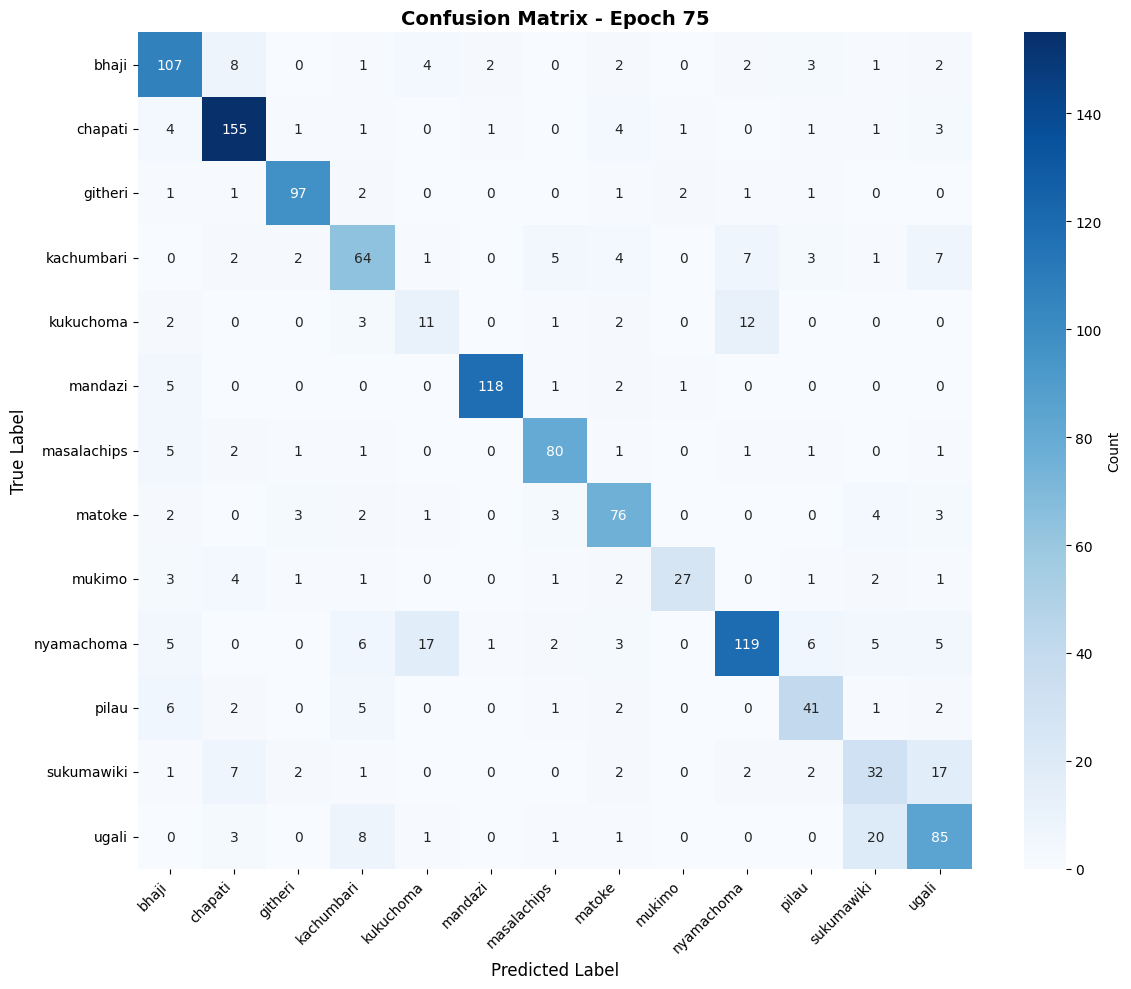

Confusion matrix saved to: confusion_matrices/conf_matrix_epoch_75.png

✨ Validation LOSS improved to: 0.7109
Saving best model...
Done.




Valid:	Epoch: 76/120	Loss: 0.7100, Acc: 0.7729: 100%|██████████| 41/41 [00:11<00:00,  3.42it/s]



Train Loss: 0.9233    Train Acc: 0.9434
Val Loss: 0.7100      Val Acc: 0.7729
Current Learning Rate: 0.00035863433532039047

⚠️ Validation did not improve. Early Stopping: 1/10




Valid:	Epoch: 77/120	Loss: 0.7093, Acc: 0.7737: 100%|██████████| 41/41 [00:12<00:00,  3.31it/s]



Train Loss: 0.9180    Train Acc: 0.9434
Val Loss: 0.7093      Val Acc: 0.7737
Current Learning Rate: 0.00034614601130971367


✨ Validation LOSS improved to: 0.7093
Saving best model...
Done.




...


Train Loss: 0.9082    Train Acc: 0.9482
Val Loss: 0.7086      Val Acc: 0.7737
Current Learning Rate: 0.00033376347381273134

⚠️ Validation did not improve. Early Stopping: 1/10




Valid:	Epoch: 79/120	Loss: 0.7083, Acc: 0.7745: 100%|██████████| 41/41 [00:12<00:00,  3.37it/s]



Train Loss: 0.9141    Train Acc: 0.9480
Val Loss: 0.7083      Val Acc: 0.7745
Current Learning Rate: 0.0003214952092021224


✨ Validation LOSS improved to: 0.7083
✨ Validation ACCURACY improved to: 0.7745
Saving best model...
Done.




Valid:	Epoch: 80/120	Loss: 0.7078, Acc: 0.7752: 100%|██████████| 41/41 [00:12<00:00,  3.31it/s]



Train Loss: 0.9175    Train Acc: 0.9438
Val Loss: 0.7078      Val Acc: 0.7752
Current Learning Rate: 0.0003093496255336376



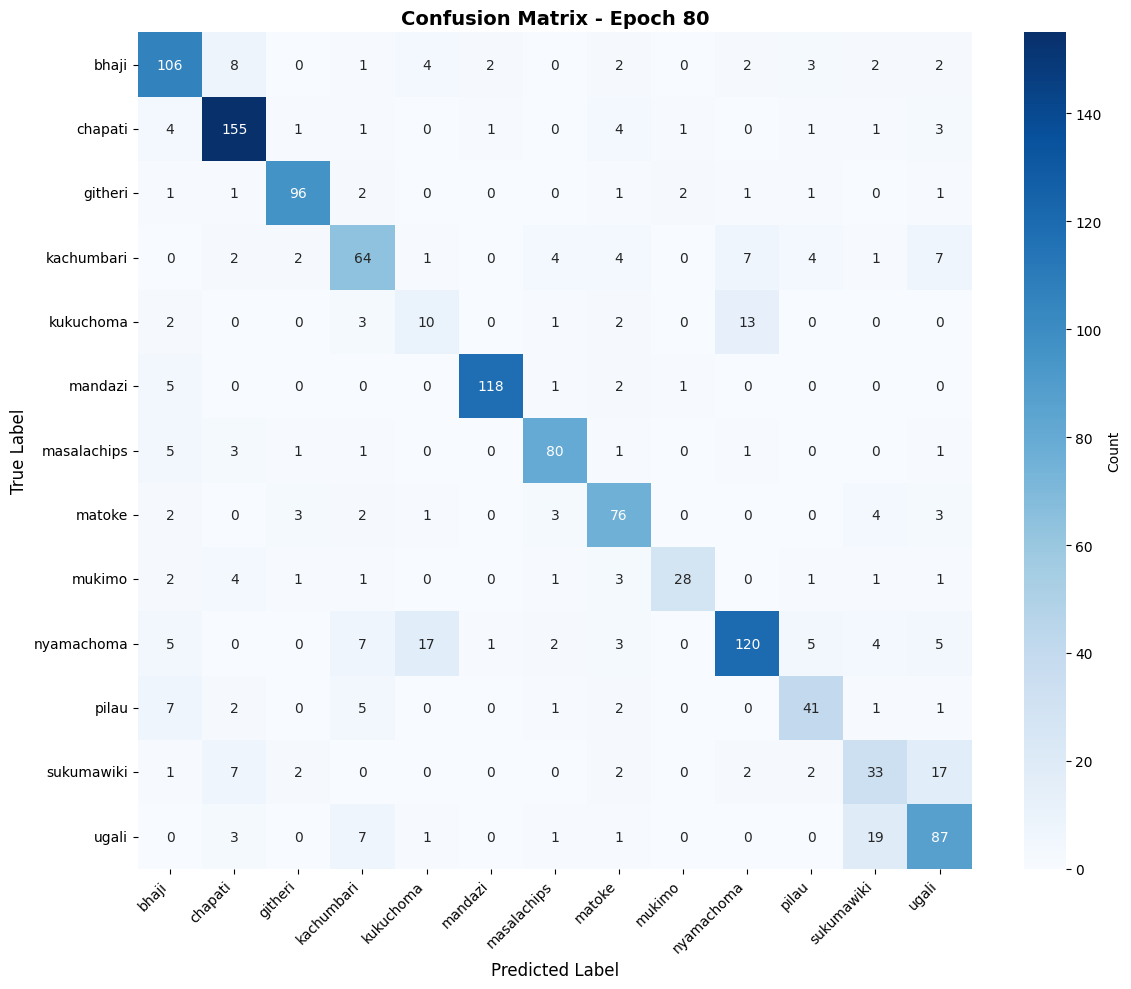

Confusion matrix saved to: confusion_matrices/conf_matrix_epoch_80.png
✨ Validation ACCURACY improved to: 0.7752
Saving best model...
Done.




Valid:	Epoch: 81/120	Loss: 0.7073, Acc: 0.7760: 100%|██████████| 41/41 [00:12<00:00,  3.33it/s]



Train Loss: 0.9176    Train Acc: 0.9464
Val Loss: 0.7073      Val Acc: 0.7760
Current Learning Rate: 0.0002973350467836378

✨ Validation ACCURACY improved to: 0.7760
Saving best model...
Done.




Valid:	Epoch: 82/120	Loss: 0.7070, Acc: 0.7768: 100%|██████████| 41/41 [00:12<00:00,  3.39it/s]



Train Loss: 0.9194    Train Acc: 0.9409
Val Loss: 0.7070      Val Acc: 0.7768
Current Learning Rate: 0.0002854597071442566


✨ Validation LOSS improved to: 0.7070
✨ Validation ACCURACY improved to: 0.7768
Saving best model...
Done.




...


Train Loss: 0.8983    Train Acc: 0.9516
Val Loss: 0.7065      Val Acc: 0.7806
Current Learning Rate: 0.00027373174538009633

✨ Validation ACCURACY improved to: 0.7806
Saving best model...
Done.




Valid:	Epoch: 84/120	Loss: 0.7060, Acc: 0.7798: 100%|██████████| 41/41 [00:12<00:00,  3.38it/s]



Train Loss: 0.9058    Train Acc: 0.9455
Val Loss: 0.7060      Val Acc: 0.7798
Current Learning Rate: 0.00026215919925032553

⚠️ Validation did not improve. Early Stopping: 1/10




Valid:	Epoch: 85/120	Loss: 0.7058, Acc: 0.7798: 100%|██████████| 41/41 [00:12<00:00,  3.38it/s]



Train Loss: 0.9008    Train Acc: 0.9529
Val Loss: 0.7058      Val Acc: 0.7798
Current Learning Rate: 0.00025075000000000005



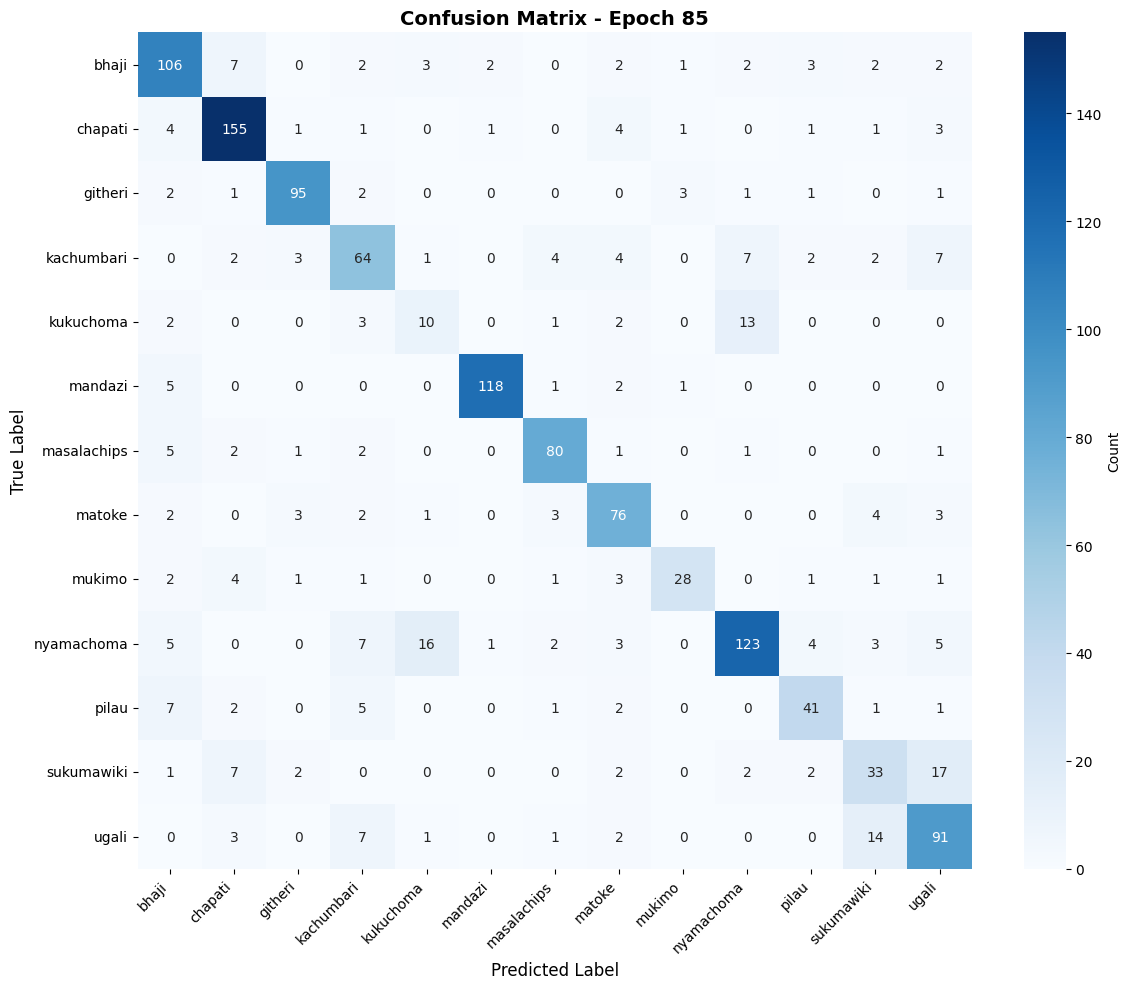

Confusion matrix saved to: confusion_matrices/conf_matrix_epoch_85.png

✨ Validation LOSS improved to: 0.7058
Saving best model...
Done.




Valid:	Epoch: 86/120	Loss: 0.7056, Acc: 0.7798: 100%|██████████| 41/41 [00:12<00:00,  3.36it/s]



Train Loss: 0.9029    Train Acc: 0.9528
Val Loss: 0.7056      Val Acc: 0.7798
Current Learning Rate: 0.00023951196692438347

⚠️ Validation did not improve. Early Stopping: 1/10




Valid:	Epoch: 87/120	Loss: 0.7052, Acc: 0.7813: 100%|██████████| 41/41 [00:12<00:00,  3.35it/s]



Train Loss: 0.9056    Train Acc: 0.9497
Val Loss: 0.7052      Val Acc: 0.7813
Current Learning Rate: 0.00022845280200999403

✨ Validation ACCURACY improved to: 0.7813
Saving best model...
Done.




...


Train Loss: 0.8986    Train Acc: 0.9545
Val Loss: 0.7049      Val Acc: 0.7813
Current Learning Rate: 0.0002175800846560458

⚠️ Validation did not improve. Early Stopping: 1/10




Valid:	Epoch: 89/120	Loss: 0.7048, Acc: 0.7813: 100%|██████████| 41/41 [00:12<00:00,  3.41it/s]



Train Loss: 0.8949    Train Acc: 0.9529
Val Loss: 0.7048      Val Acc: 0.7813
Current Learning Rate: 0.00020690126647990965


✨ Validation LOSS improved to: 0.7048
Saving best model...
Done.




Valid:	Epoch: 90/120	Loss: 0.7047, Acc: 0.7813: 100%|██████████| 41/41 [00:12<00:00,  3.39it/s]



Train Loss: 0.8941    Train Acc: 0.9556
Val Loss: 0.7047      Val Acc: 0.7813
Current Learning Rate: 0.00019642366621014398



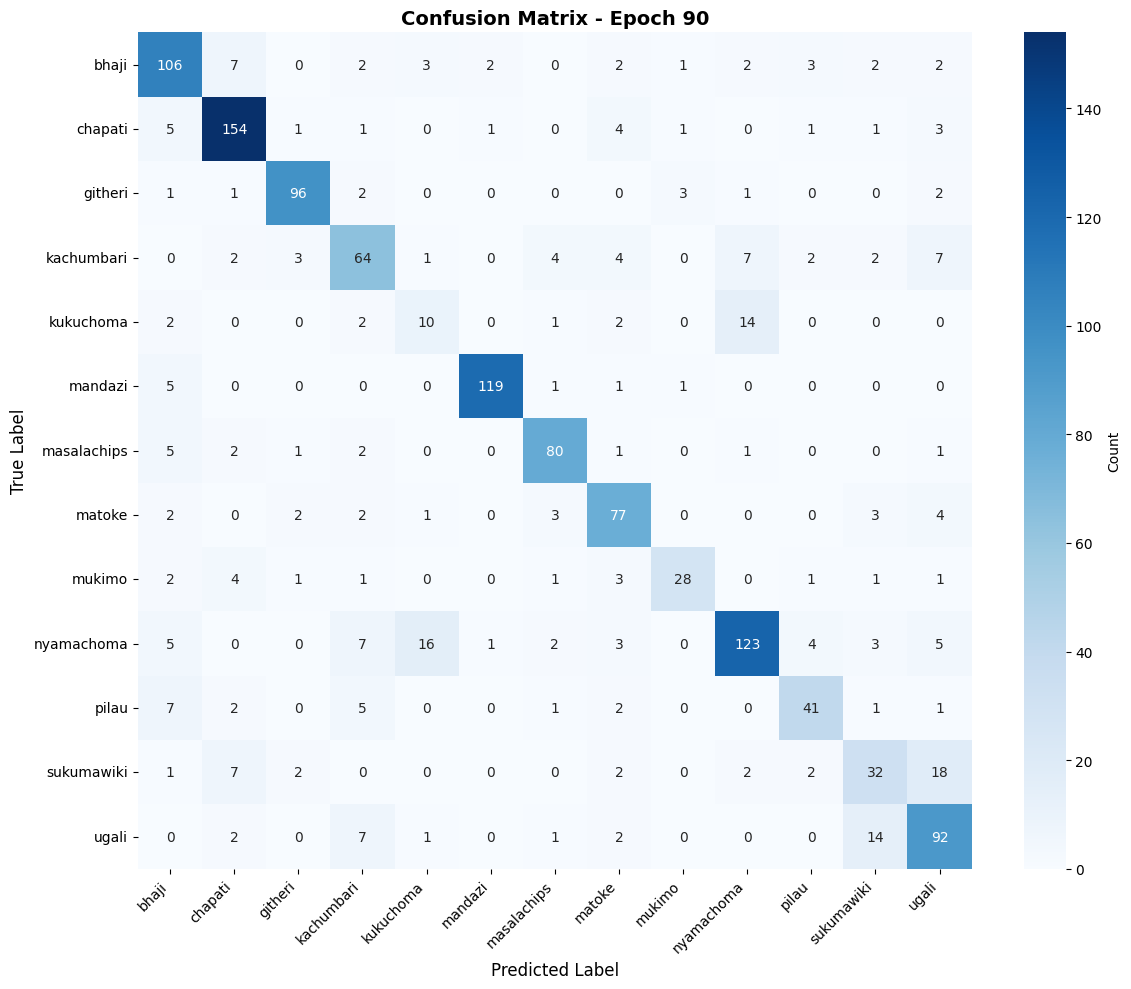

Confusion matrix saved to: confusion_matrices/conf_matrix_epoch_90.png
⚠️ Validation did not improve. Early Stopping: 1/10




Valid:	Epoch: 91/120	Loss: 0.7048, Acc: 0.7836: 100%|██████████| 41/41 [00:12<00:00,  3.31it/s]



Train Loss: 0.8921    Train Acc: 0.9583
Val Loss: 0.7048      Val Acc: 0.7836
Current Learning Rate: 0.00018615446467060623

✨ Validation ACCURACY improved to: 0.7836
Saving best model...
Done.




Valid:	Epoch: 92/120	Loss: 0.7049, Acc: 0.7829: 100%|██████████| 41/41 [00:12<00:00,  3.38it/s]



Train Loss: 0.8888    Train Acc: 0.9570
Val Loss: 0.7049      Val Acc: 0.7829
Current Learning Rate: 0.00017610069985907328

⚠️ Validation did not improve. Early Stopping: 1/10




...


Train Loss: 0.8859    Train Acc: 0.9589
Val Loss: 0.7050      Val Acc: 0.7821
Current Learning Rate: 0.00016626926212375044

⚠️ Validation did not improve. Early Stopping: 2/10




Valid:	Epoch: 94/120	Loss: 0.7052, Acc: 0.7813: 100%|██████████| 41/41 [00:12<00:00,  3.41it/s]



Train Loss: 0.8873    Train Acc: 0.9577
Val Loss: 0.7052      Val Acc: 0.7813
Current Learning Rate: 0.00015666688944096976

⚠️ Validation did not improve. Early Stopping: 3/10




Valid:	Epoch: 95/120	Loss: 0.7054, Acc: 0.7821: 100%|██████████| 41/41 [00:11<00:00,  3.42it/s]



Train Loss: 0.8953    Train Acc: 0.9501
Val Loss: 0.7054      Val Acc: 0.7821
Current Learning Rate: 0.0001473001627973195



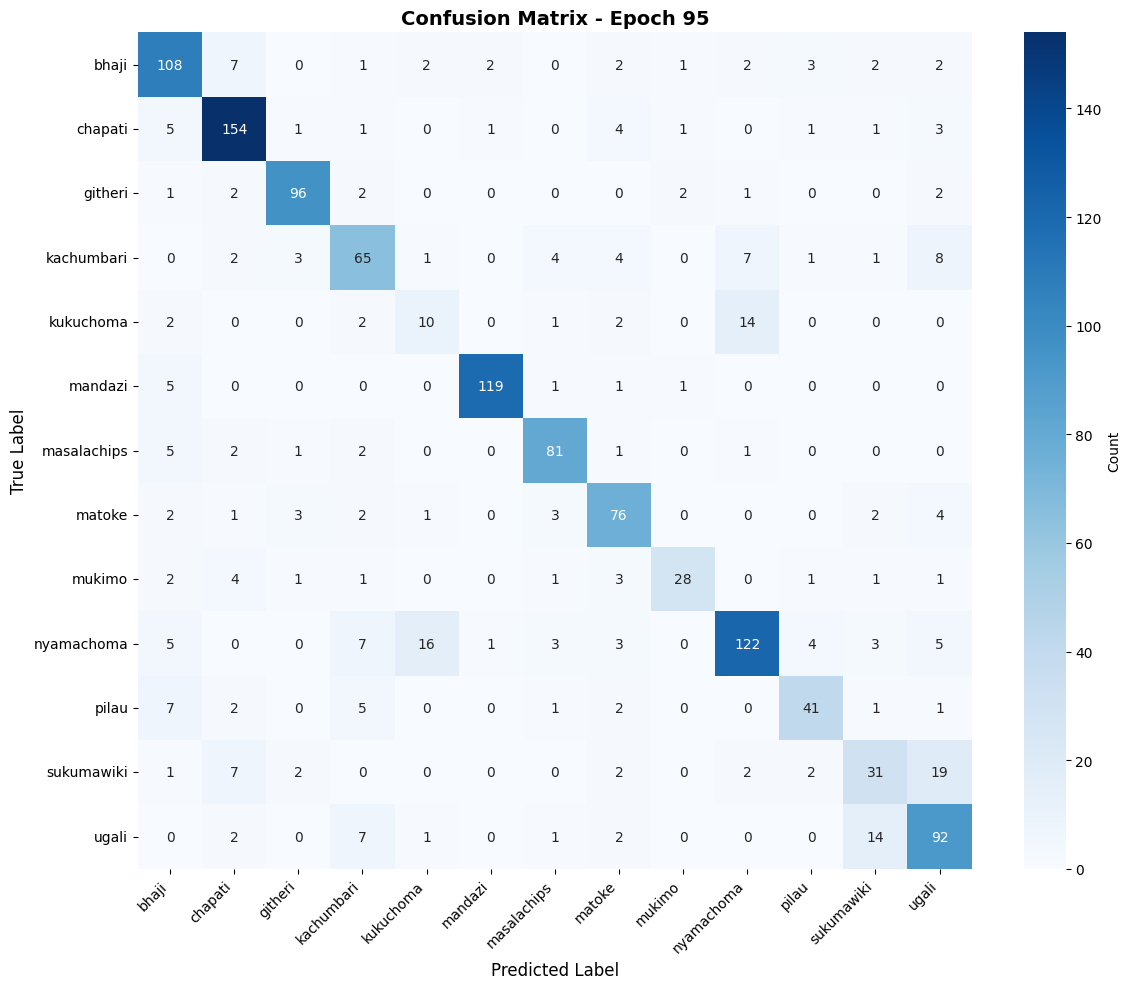

Confusion matrix saved to: confusion_matrices/conf_matrix_epoch_95.png
⚠️ Validation did not improve. Early Stopping: 4/10




Valid:	Epoch: 96/120	Loss: 0.7057, Acc: 0.7829: 100%|██████████| 41/41 [00:12<00:00,  3.36it/s]



Train Loss: 0.8876    Train Acc: 0.9566
Val Loss: 0.7057      Val Acc: 0.7829
Current Learning Rate: 0.0001381755016793623

⚠️ Validation did not improve. Early Stopping: 5/10




Valid:	Epoch: 97/120	Loss: 0.7060, Acc: 0.7829: 100%|██████████| 41/41 [00:12<00:00,  3.28it/s]



Train Loss: 0.8768    Train Acc: 0.9617
Val Loss: 0.7060      Val Acc: 0.7829
Current Learning Rate: 0.00012929915967404166

⚠️ Validation did not improve. Early Stopping: 6/10




...


Train Loss: 0.8817    Train Acc: 0.9600
Val Loss: 0.7062      Val Acc: 0.7836
Current Learning Rate: 0.00012067722018278452

⚠️ Validation did not improve. Early Stopping: 7/10




Valid:	Epoch: 99/120	Loss: 0.7065, Acc: 0.7852: 100%|██████████| 41/41 [00:12<00:00,  3.39it/s]



Train Loss: 0.8749    Train Acc: 0.9627
Val Loss: 0.7065      Val Acc: 0.7852
Current Learning Rate: 0.000112315592252243

✨ Validation ACCURACY improved to: 0.7852
Saving best model...
Done.




Valid:	Epoch: 100/120	Loss: 0.7069, Acc: 0.7844: 100%|██████████| 41/41 [00:12<00:00,  3.38it/s]



Train Loss: 0.8826    Train Acc: 0.9573
Val Loss: 0.7069      Val Acc: 0.7844
Current Learning Rate: 0.00010422000652452795



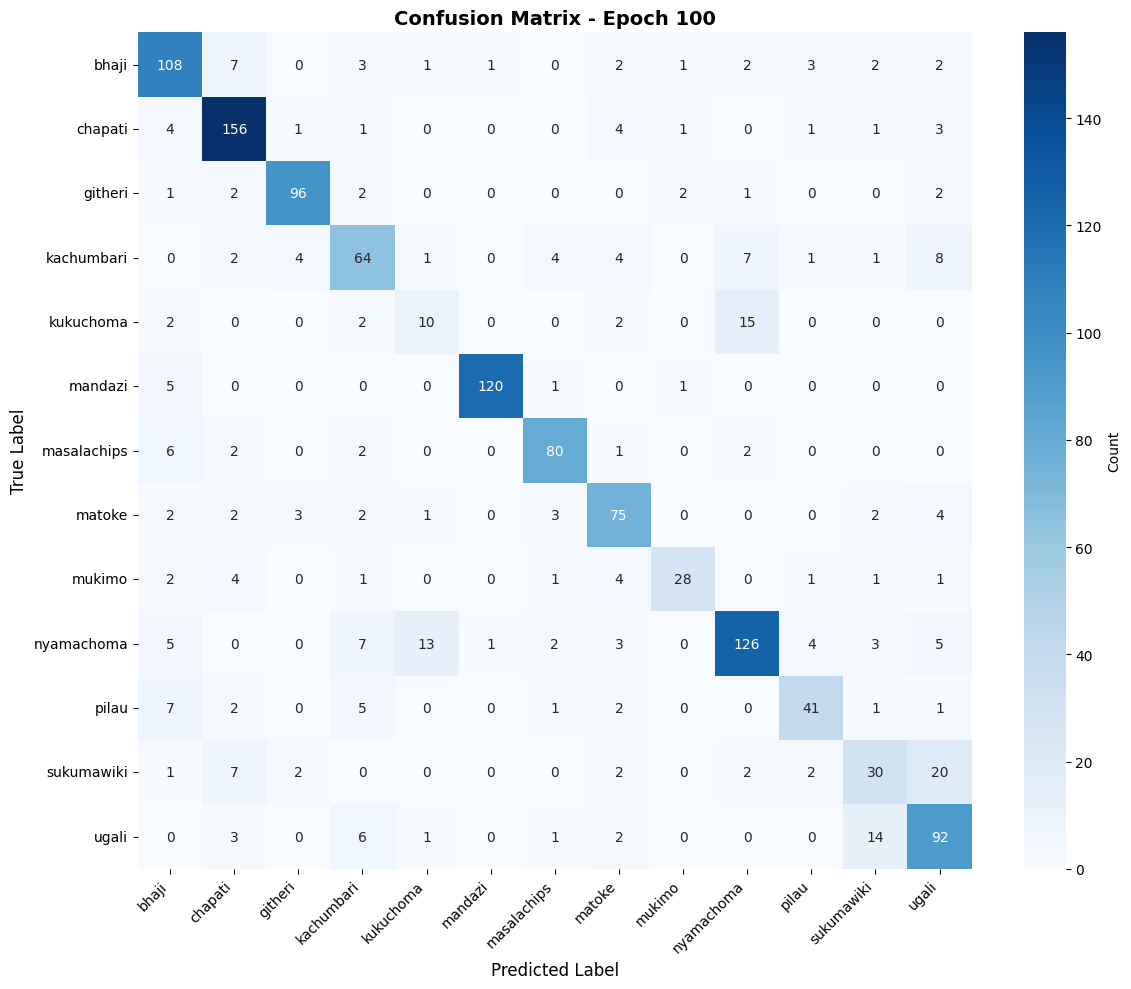

Confusion matrix saved to: confusion_matrices/conf_matrix_epoch_100.png
⚠️ Validation did not improve. Early Stopping: 1/10




Valid:	Epoch: 101/120	Loss: 0.7071, Acc: 0.7836: 100%|██████████| 41/41 [00:11<00:00,  3.45it/s]



Train Loss: 0.8822    Train Acc: 0.9612
Val Loss: 0.7071      Val Acc: 0.7836
Current Learning Rate: 9.639601130971378e-05

⚠️ Validation did not improve. Early Stopping: 2/10




Valid:	Epoch: 102/120	Loss: 0.7072, Acc: 0.7836: 100%|██████████| 41/41 [00:12<00:00,  3.31it/s]



Train Loss: 0.8823    Train Acc: 0.9594
Val Loss: 0.7072      Val Acc: 0.7836
Current Learning Rate: 8.884896878330324e-05

⚠️ Validation did not improve. Early Stopping: 3/10




...


Train Loss: 0.8816    Train Acc: 0.9573
Val Loss: 0.7073      Val Acc: 0.7844
Current Learning Rate: 8.158405131126072e-05

⚠️ Validation did not improve. Early Stopping: 4/10




Valid:	Epoch: 104/120	Loss: 0.7073, Acc: 0.7844: 100%|██████████| 41/41 [00:12<00:00,  3.32it/s]



Train Loss: 0.8805    Train Acc: 0.9616
Val Loss: 0.7073      Val Acc: 0.7844
Current Learning Rate: 7.460623790513095e-05

⚠️ Validation did not improve. Early Stopping: 5/10




Valid:	Epoch: 105/120	Loss: 0.7074, Acc: 0.7859: 100%|██████████| 41/41 [00:12<00:00,  3.32it/s]



Train Loss: 0.8856    Train Acc: 0.9575
Val Loss: 0.7074      Val Acc: 0.7859
Current Learning Rate: 6.792031080967285e-05



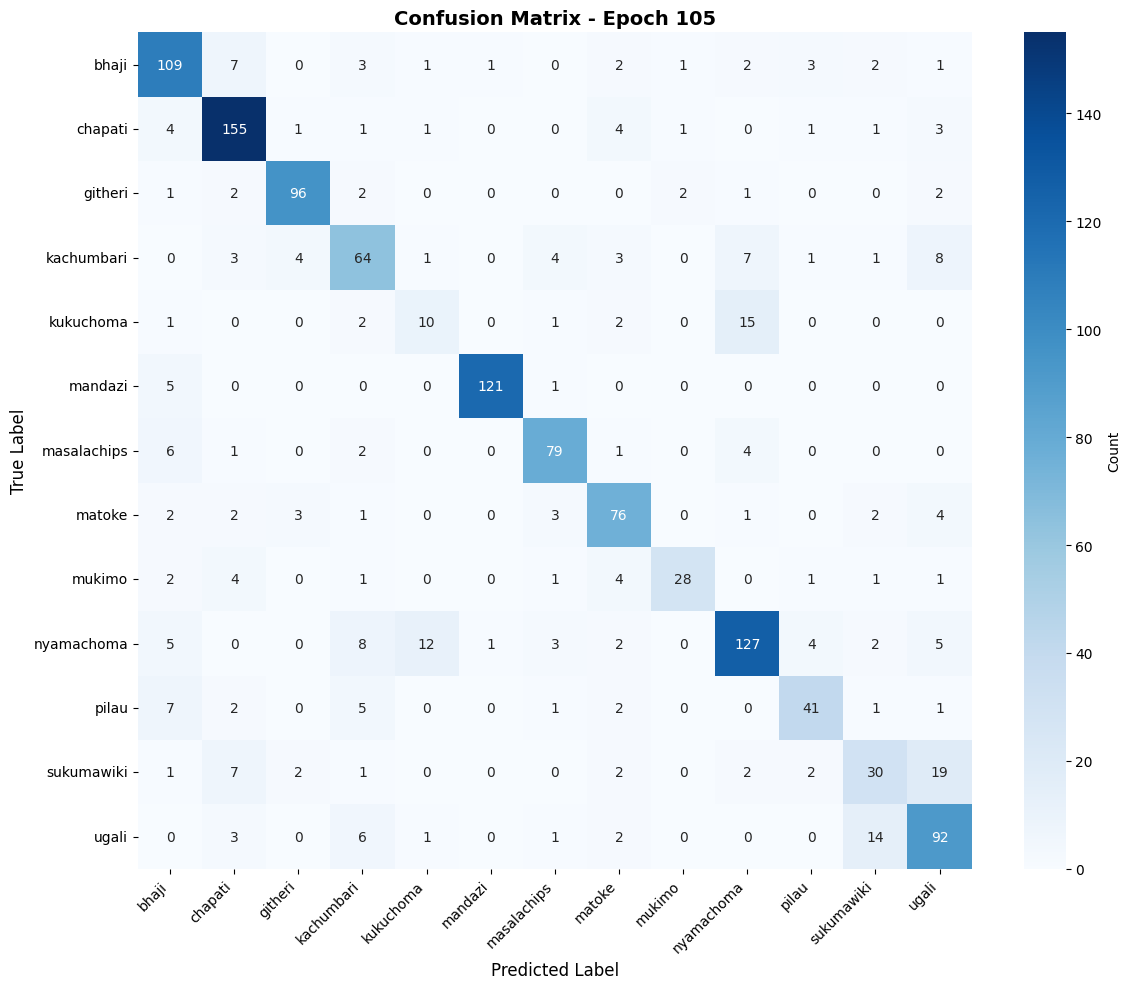

Confusion matrix saved to: confusion_matrices/conf_matrix_epoch_105.png
✨ Validation ACCURACY improved to: 0.7859
Saving best model...
Done.




Valid:	Epoch: 106/120	Loss: 0.7078, Acc: 0.7875: 100%|██████████| 41/41 [00:11<00:00,  3.43it/s]



Train Loss: 0.8777    Train Acc: 0.9593
Val Loss: 0.7078      Val Acc: 0.7875
Current Learning Rate: 6.153085222534833e-05

✨ Validation ACCURACY improved to: 0.7875
Saving best model...
Done.




Valid:	Epoch: 107/120	Loss: 0.7081, Acc: 0.7852: 100%|██████████| 41/41 [00:12<00:00,  3.32it/s]



Train Loss: 0.8774    Train Acc: 0.9600
Val Loss: 0.7081      Val Acc: 0.7852
Current Learning Rate: 5.544224116791028e-05

⚠️ Validation did not improve. Early Stopping: 1/10




...


Train Loss: 0.8775    Train Acc: 0.9598
Val Loss: 0.7086      Val Acc: 0.7844
Current Learning Rate: 4.9658650467244715e-05

⚠️ Validation did not improve. Early Stopping: 2/10




Valid:	Epoch: 109/120	Loss: 0.7088, Acc: 0.7859: 100%|██████████| 41/41 [00:12<00:00,  3.40it/s]



Train Loss: 0.8735    Train Acc: 0.9631
Val Loss: 0.7088      Val Acc: 0.7859
Current Learning Rate: 4.4184043907520803e-05

⚠️ Validation did not improve. Early Stopping: 3/10




Valid:	Epoch: 110/120	Loss: 0.7092, Acc: 0.7836: 100%|██████████| 41/41 [00:12<00:00,  3.29it/s]



Train Loss: 0.8722    Train Acc: 0.9627
Val Loss: 0.7092      Val Acc: 0.7836
Current Learning Rate: 3.902217351061227e-05



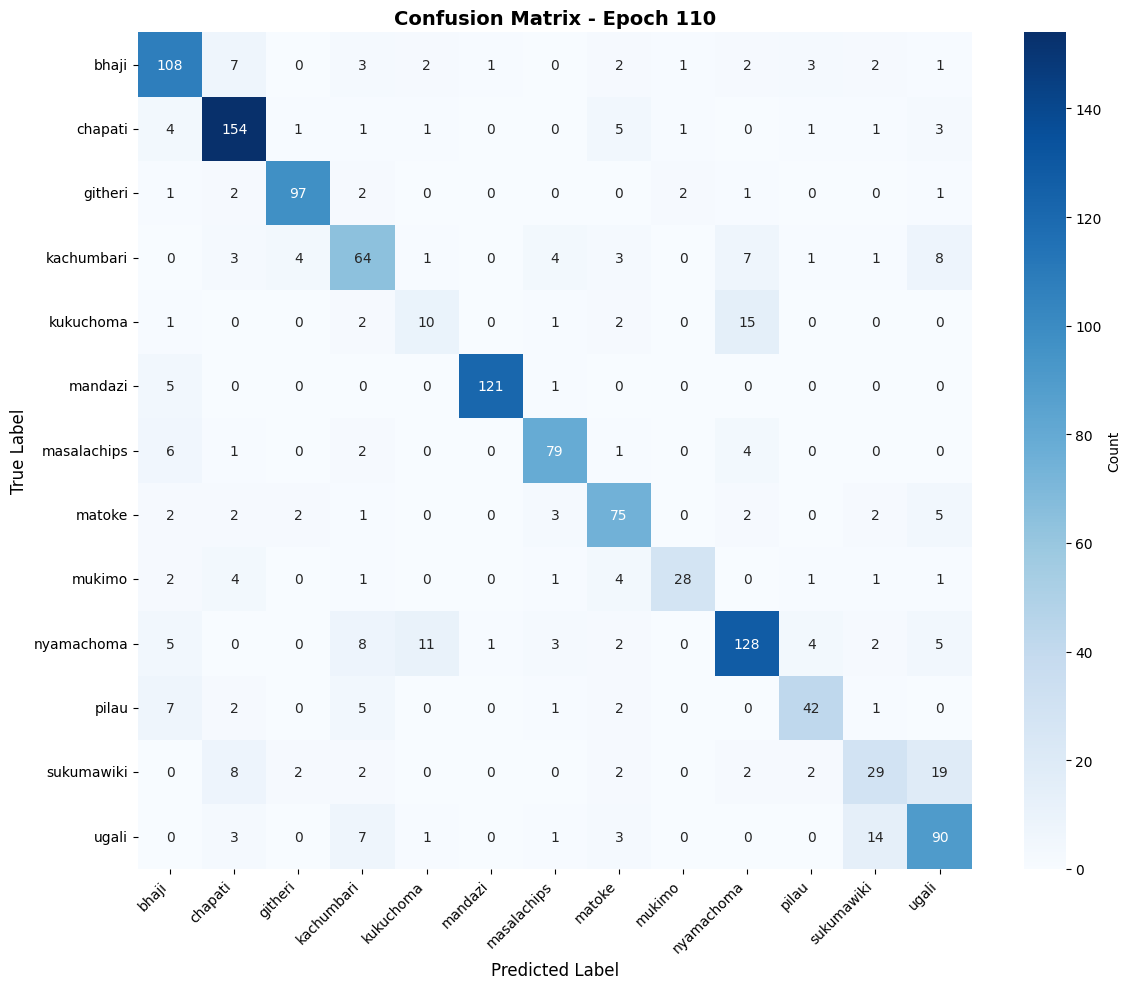

Confusion matrix saved to: confusion_matrices/conf_matrix_epoch_110.png
⚠️ Validation did not improve. Early Stopping: 4/10




Valid:	Epoch: 111/120	Loss: 0.7096, Acc: 0.7844: 100%|██████████| 41/41 [00:12<00:00,  3.32it/s]



Train Loss: 0.8739    Train Acc: 0.9638
Val Loss: 0.7096      Val Acc: 0.7844
Current Learning Rate: 3.417657696464772e-05

⚠️ Validation did not improve. Early Stopping: 5/10




Valid:	Epoch: 112/120	Loss: 0.7098, Acc: 0.7852: 100%|██████████| 41/41 [00:12<00:00,  3.34it/s]



Train Loss: 0.8733    Train Acc: 0.9619
Val Loss: 0.7098      Val Acc: 0.7852
Current Learning Rate: 2.965057519945693e-05

⚠️ Validation did not improve. Early Stopping: 6/10




...


Train Loss: 0.8743    Train Acc: 0.9616
Val Loss: 0.7100      Val Acc: 0.7859
Current Learning Rate: 2.544727011057081e-05

⚠️ Validation did not improve. Early Stopping: 7/10




Valid:	Epoch: 114/120	Loss: 0.7103, Acc: 0.7859: 100%|██████████| 41/41 [00:12<00:00,  3.34it/s]



Train Loss: 0.8725    Train Acc: 0.9677
Val Loss: 0.7103      Val Acc: 0.7859
Current Learning Rate: 2.1569542433337623e-05

⚠️ Validation did not improve. Early Stopping: 8/10




Valid:	Epoch: 115/120	Loss: 0.7107, Acc: 0.7852: 100%|██████████| 41/41 [00:12<00:00,  3.37it/s]



Train Loss: 0.8729    Train Acc: 0.9633
Val Loss: 0.7107      Val Acc: 0.7852
Current Learning Rate: 1.8020049768610376e-05



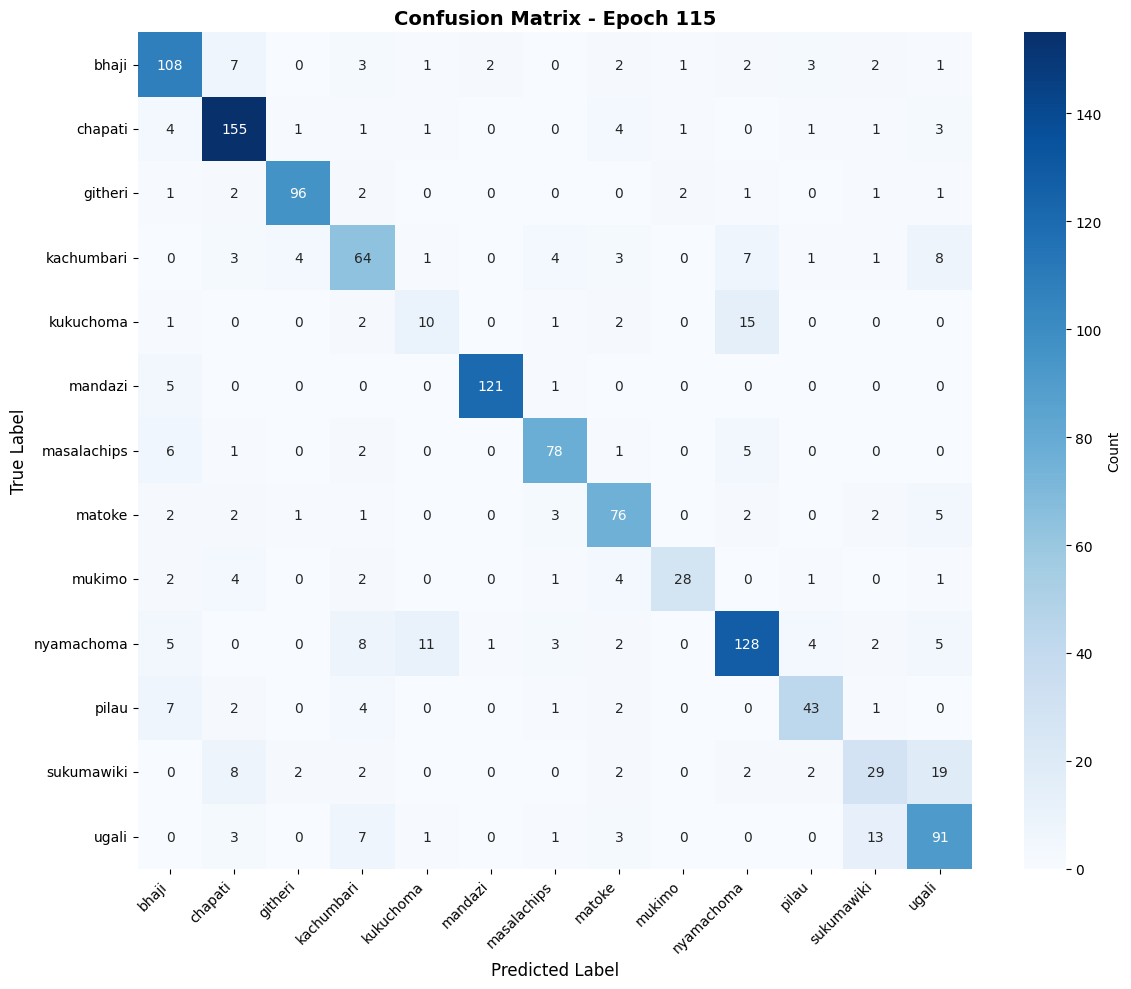

Confusion matrix saved to: confusion_matrices/conf_matrix_epoch_115.png
⚠️ Validation did not improve. Early Stopping: 9/10




Valid:	Epoch: 116/120	Loss: 0.7109, Acc: 0.7867: 100%|██████████| 41/41 [00:12<00:00,  3.41it/s]



Train Loss: 0.8721    Train Acc: 0.9631
Val Loss: 0.7109      Val Acc: 0.7867
Current Learning Rate: 1.480122476136056e-05

⚠️ Validation did not improve. Early Stopping: 10/10

Early Stopping Triggered! Training stopped at epoch 116 to avoid overfitting.

Total time: 22951.28s, Best Loss: 0.705

Generating final confusion matrix on best model...


Valid:	Epoch: 120/120	Loss: 0.7078, Acc: 0.7875: 100%|██████████| 41/41 [00:12<00:00,  3.40it/s]


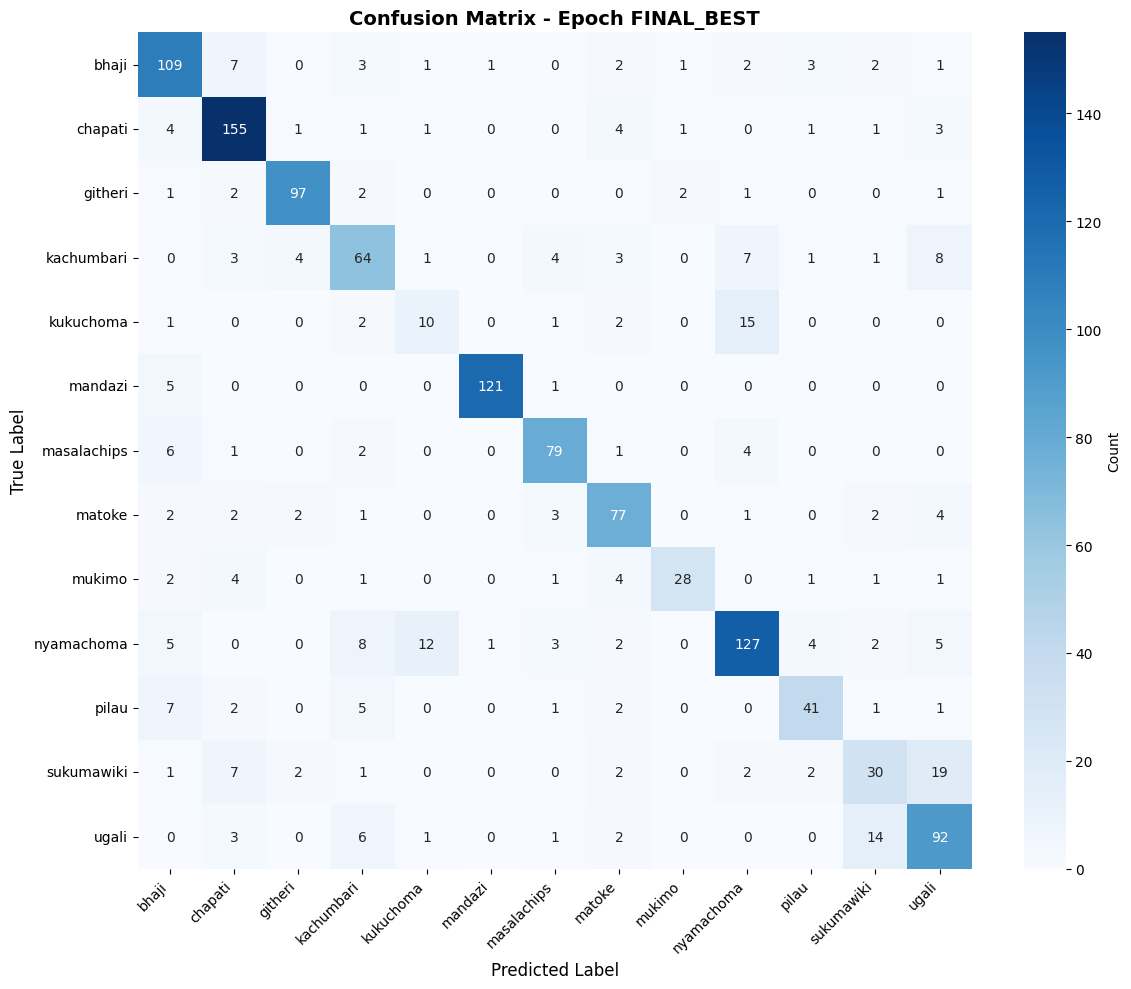

Confusion matrix saved to: confusion_matrices/conf_matrix_epoch_FINAL_BEST.png


In [36]:
writer = SummaryWriter(TrainingConfig.LOG_DIR)

history = main(
    DEVICE,
    model = model_net,
    optimizer = optimizer_net,
    ema_model=ema,
    ckpt_dir = CKPT_DIR,
    summary_writer =  writer,
    data_config = DatasetConfig(),
    train_config = TrainingConfig(),
    class_to_idx = class_to_idx
)

writer.close()

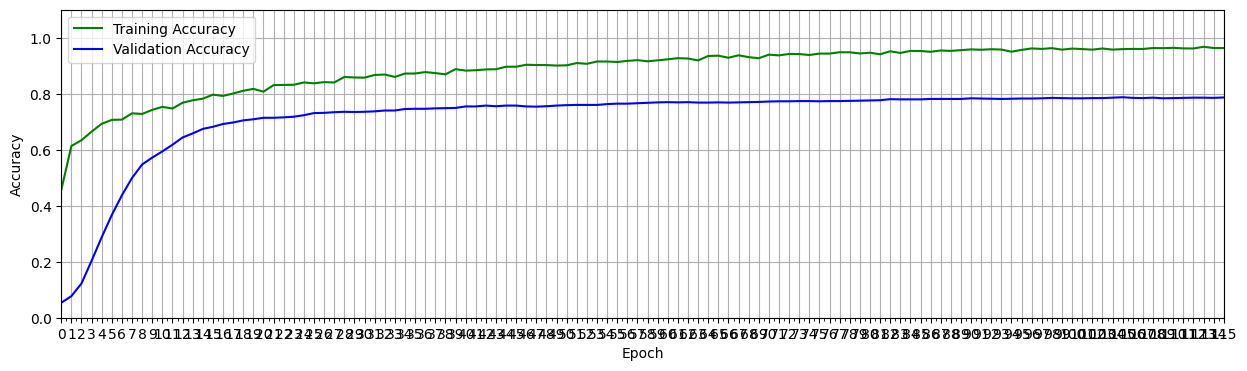

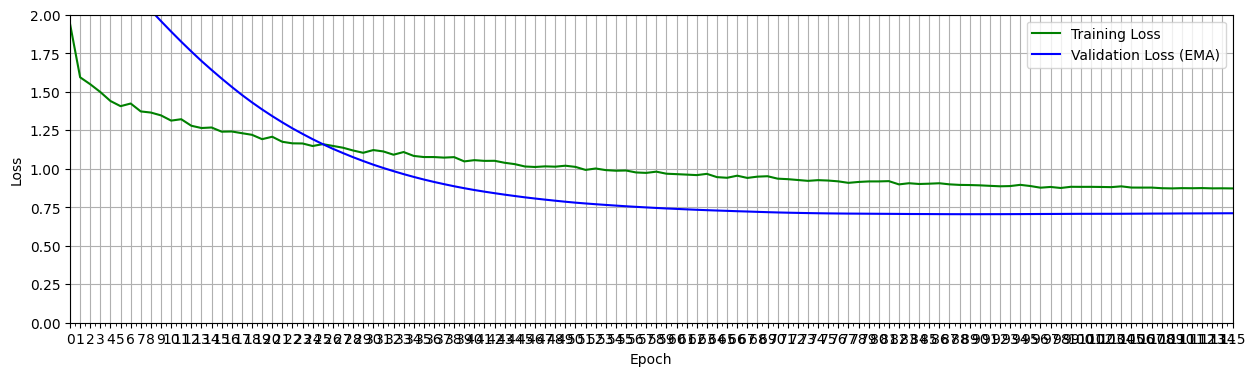

In [37]:
# Retrieve training results.
train_loss = history["train_loss"]
train_acc  = history["train_acc"]
valid_loss = history["valid_loss"]
valid_acc  = history["valid_acc"]

train_config = history["train_config"]

plot_results([ train_acc, valid_acc ],
            ylabel="Accuracy",
            ylim = [0.0, 1.1],
            metric_name=["Training Accuracy", "Validation Accuracy"],
            color=["g", "b"],
            training_config=TrainingConfig())

plot_results([ train_loss, valid_loss ],
            ylabel="Loss",
            ylim = [0.0, 2.0],
            metric_name=["Training Loss", "Validation Loss (EMA)"],
            color=["g", "b"],
            training_config=TrainingConfig());

In [38]:
def prediction_batch(model: nn.Module, 
                     batch_inputs: torch.Tensor, 
                     device: torch.device):
    
    # Ensure model is in evaluation mode
    model.eval()

    # Move inputs to the correct device (CPU/CUDA)
    batch_inputs = batch_inputs.to(device)

    # Forward pass without tracking gradients
    with torch.no_grad():
        batch_ops = model(batch_inputs)

    # Calculate probabilities
    batch_probs = batch_ops.softmax(dim=1)

    # Extract max confidence values and their respective class IDs
    batch_confs, batch_cls_ids = batch_probs.max(dim=1)

    # Return them as separate tensors on the CPU
    return batch_confs.cpu(), batch_cls_ids.cpu()

In [39]:
# Load best EMA weights
checkpoint_path = os.path.join(TrainingConfig.CHECKPOINT_DIR, "best_ema_model.pth")

if os.path.exists(checkpoint_path):
    print(f"Loading best EMA weights from: {checkpoint_path}")
    
    # Load the weights dictionary safely to your current active device
    best_weights = torch.load(checkpoint_path, map_location=DEVICE)
    
    # Inject the saved weights back into your model instance
    model_net.load_state_dict(best_weights)
    
    # Send model to accelerator and lock model state for validation testing
    model_net = model_net.to(DEVICE)
    model_net.eval()
    print("--> Best EMA model restored for inference!")
else:
    print(f"CRITICAL WARNING: Checkpoint file not found at {checkpoint_path}!")
    print("Inference will continue using your current, un-restored model weights (Epoch 10 structure).")

Loading best EMA weights from: model_checkpoint/kenya_food_models/best_ema_model.pth
--> Best EMA model restored for inference!


In [40]:
# Setup containers
all_confs = []
all_preds = []
all_ids = []

# Loop through the unlabelled test data
for images, ids in test_loader:
    # Get predictions using your function
    confs, preds = prediction_batch(model_net, images, DEVICE)
    
    # Store results
    all_confs.extend(confs.numpy())
    all_preds.extend(preds.numpy())
    all_ids.extend(ids)

# Create a clean final dataframe
results_df = pd.DataFrame({
    'id': all_ids,
    'class_id': all_preds,
    'confidence': all_confs
})

In [41]:
# Grab the original class_to_idx mapping from your training dataset
class_to_idx = train_loader.dataset.class_to_idx

# Invert the dictionary: turns { 'ugali': 0 } into { 0: 'ugali' }
idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}

# Use pandas .map() to create the new column
results_df['class_name'] = results_df['class_id'].map(idx_to_class)

In [42]:
# Keep only the columns needed for submission
submission_df = results_df[['id', 'class_name']]

# Rename columns if the competition requires specific headers (e.g., 'label')
submission_df = submission_df.rename(columns={'class_name': 'class'})

# Save it to a CSV file
submission_df.to_csv('kenyan_food_submission.csv', index=False)

## <font style="color:green">8. TensorBoard Log Link [5 Points]</font>

**Share your TensorBoard scalars logs link here You can also share (not mandatory) your GitHub link, if you have pushed this project in GitHub.**


Note: In light of the recent shutdown of tensorboard.dev, we have updated the submission requirements for your project. Instead of sharing a tensorboard.dev link, you are now required to upload your generated TensorBoard event files directly onto the lab. As an alternative, you may also include a screenshot of your TensorBoard output within your Jupyter notebook. This adjustment ensures that your data visualization and model training efforts are thoroughly documented and accessible for evaluation.

You are also welcome (and encouraged) to utilize alternative logging services like wandB or comet. In such instances, you can easily make your project logs publicly accessible and share the link with others.

## <font style="color:green">9. Kaggle Profile Link [50 Points]</font>

**Share your Kaggle profile link  with us here to score , points in  the competition.**

**For full points, you need a minimum accuracy of `75%` on the test data. If accuracy is less than `70%`, you gain  no points for this section.**


**Submit `submission.csv` (prediction for images in `test.csv`), in the `Submit Predictions` tab in Kaggle, to get evaluated for  this section.**